In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
#evaluation
from sklearn.metrics import silhouette_score
#import dataset
from sklearn.datasets import load_iris

#distance matrix (dbscan elbow, hierarchical)
from scipy.spatial.distance import pdist, squareform

In [51]:
df = pd.read_csv("./dataset/DM1_game_dataset_cleaned.csv")

df.columns

Index(['Name', 'YearPublished', 'GameWeight', 'MinPlayers', 'MaxPlayers',
       'MfgPlaytime', 'MfgAgeRec', 'NumAlternates', 'NumExpansions',
       'NumImplementations', 'IsReimplementation', 'Kickstarted', 'Rating',
       'HasFamily', 'Category', 'Rank', 'EngagementLevel'],
      dtype='object')

In [6]:
# --- 1. Select numeric columns ---
df_num = df.select_dtypes(include=['float64', 'int64'])

# Remove binaries and Rank columns
numeric_cols = [col for col in df_num.columns if df_num[col].nunique() > 2 and 'Rank' not in col]
df_num = df_num[numeric_cols].copy()

# --- 2. Fix YearPublished (recency) ---
if 'YearPublished' in df_num.columns:
    current_year = df['YearPublished'].max()
    df_num['YearPublished'] = current_year - df_num['YearPublished']

# --- 3. Exclude columns with high zero values ---
zero_threshold = 0.5
cols_to_exclude = [col for col in df_num.columns if (df_num[col] == 0).mean() > zero_threshold]
df_num.drop(columns=cols_to_exclude, inplace=True)
print("Excluded columns due to high zero values:", cols_to_exclude)

# log transform skewed columns except EngagementLevel
skewed_cols = df_num.skew().abs()
log_cols = skewed_cols[((skewed_cols > 1.0) | (skewed_cols < -1.0)) & (skewed_cols.index != 'EngagementLevel')].index.tolist()
df_num[log_cols] = df_num[log_cols].apply(np.log1p)
print("Log-transforming columns:", log_cols)


# --- 4. Standardize BEFORE outlier detection ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)



Excluded columns due to high zero values: ['NumAlternates', 'NumExpansions', 'NumImplementations']
Log-transforming columns: ['YearPublished', 'MinPlayers', 'MaxPlayers', 'MfgPlaytime']


In [53]:
df_num.columns

Index(['YearPublished', 'GameWeight', 'MinPlayers', 'MaxPlayers',
       'MfgPlaytime', 'MfgAgeRec', 'EngagementLevel'],
      dtype='object')

In [7]:
dist = pdist(X_scaled, 'euclidean')
dist = squareform(dist)

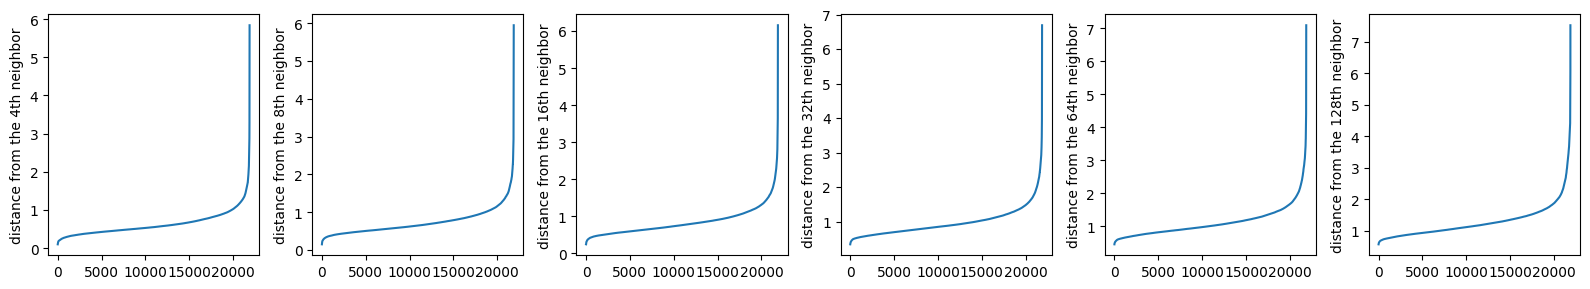

In [ ]:

ks = [4, 8, 16, 32, 64, 128]

fig = plt.figure(figsize=(16, 3)) # dimensions of the overall plot
fig_dims = (1, len(ks))

for i in range(len(ks)):
    k = ks[i]
    kth_distances = []

    for d in dist:  # d is a vector containing distances between the ith record and all the others
        index_kth_distance = np.argsort(d)[k]  # take the index of the kth nearest neighbor
        kth_distances.append(d[index_kth_distance])  # store the distance in a list

    plt.subplot2grid(fig_dims, (0, i))
    plt.plot(range(0, len(kth_distances)), sorted(kth_distances))
    plt.ylabel('distance from the {}th neighbor'.format(k))

plt.tight_layout()
plt.show()

In [164]:
for eps in [1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9]:
    print('DBSCAN with eps =', eps)
    dbscan = DBSCAN(eps=eps, min_samples=64, metric='precomputed')
    dbscan.fit(dist)
    print('Number of clusters:', len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0))
    print("Cluster sizes:", np.bincount(dbscan.labels_[dbscan.labels_ != -1]))
    print('Number of noise points:', list(dbscan.labels_).count(-1))
    print('Silhouette', silhouette_score(X_scaled[dbscan.labels_ != -1], dbscan.labels_[dbscan.labels_ != -1]))
    print('---')

DBSCAN with eps = 1.1
Number of clusters: 3
Cluster sizes: [14048  2146  2484]
Number of noise points: 3201
Silhouette 0.08979187214334623
---
DBSCAN with eps = 1.2
Number of clusters: 3
Cluster sizes: [14323  2436  2979]
Number of noise points: 2141
Silhouette 0.1013316192685386
---
DBSCAN with eps = 1.3
Number of clusters: 3
Cluster sizes: [14498  3324  2609]
Number of noise points: 1448
Silhouette 0.10724796931896993
---
DBSCAN with eps = 1.4
Number of clusters: 2
Cluster sizes: [17344  3477]
Number of noise points: 1058
Silhouette 0.20332361116915756
---
DBSCAN with eps = 1.5
Number of clusters: 2
Cluster sizes: [17477  3548]
Number of noise points: 854
Silhouette 0.20269586852972327
---
DBSCAN with eps = 1.6
Number of clusters: 2
Cluster sizes: [17577  3583]
Number of noise points: 719
Silhouette 0.20185622844365012
---
DBSCAN with eps = 1.7
Number of clusters: 3
Cluster sizes: [17644  3611    99]
Number of noise points: 525
Silhouette 0.20024263106539172
---
DBSCAN with eps = 1.8

In [52]:
dbscan = DBSCAN(eps=1.3, min_samples=64, metric='precomputed')
dbscan.fit(dist)

,eps,1.3
,min_samples,64
,metric,'precomputed'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [53]:
print('Silhouette', silhouette_score(X_scaled[dbscan.labels_ != -1], dbscan.labels_[dbscan.labels_ != -1]))

Silhouette 0.10724796931896993


In [55]:
print("Noise percentage:", (list(dbscan.labels_).count(-1) / len(dbscan.labels_)) * 100)

Noise percentage: 6.618218382924265


<Figure size 1000x600 with 0 Axes>

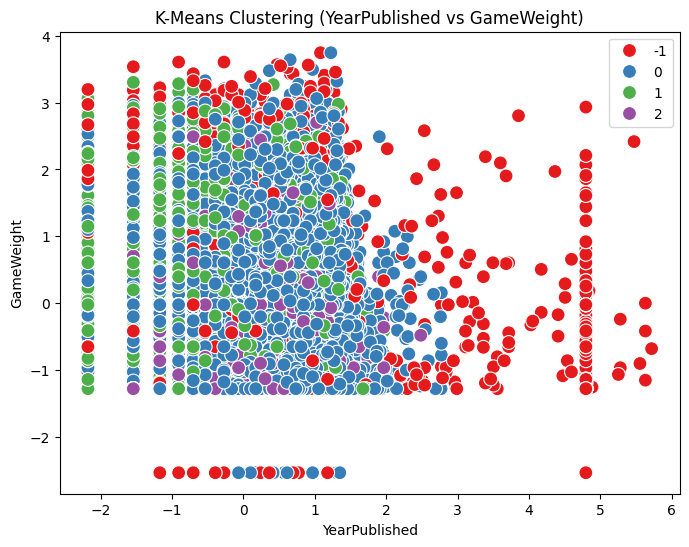

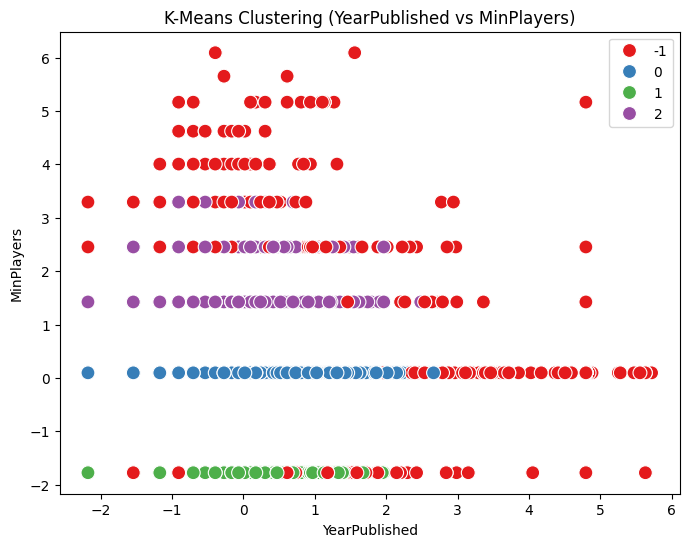

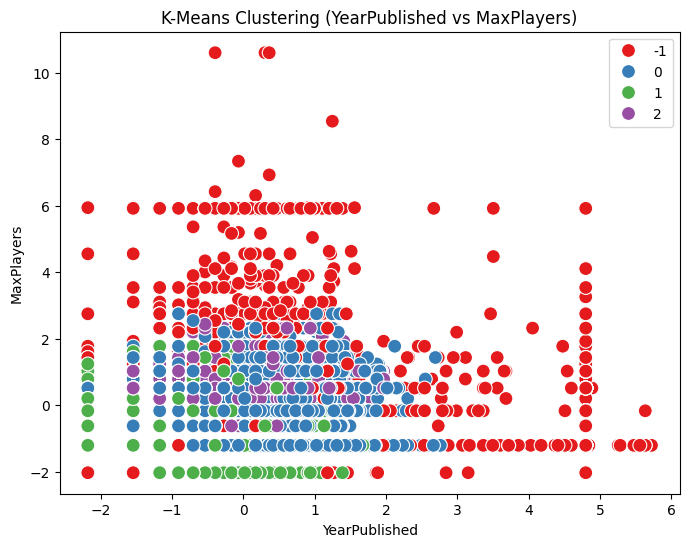

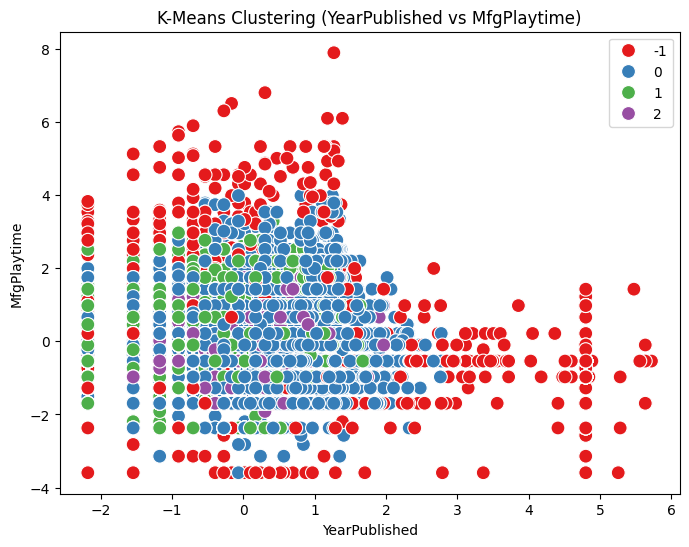

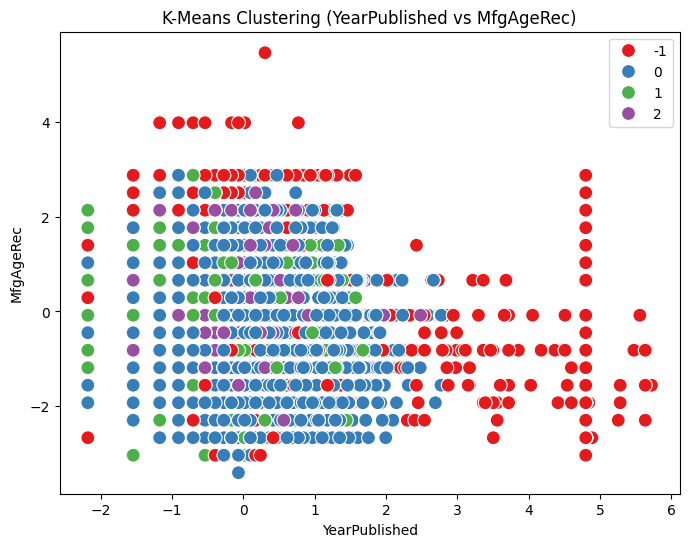

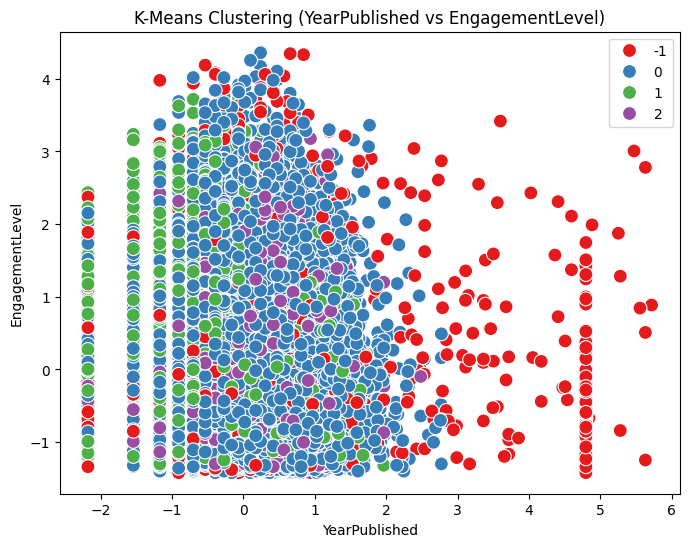

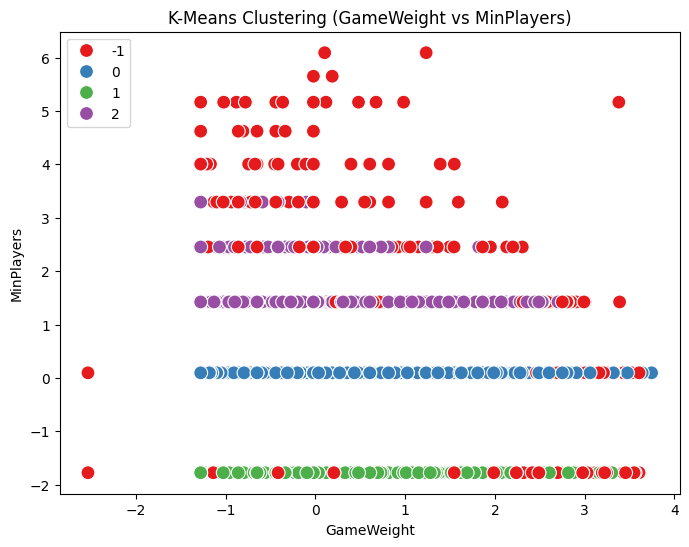

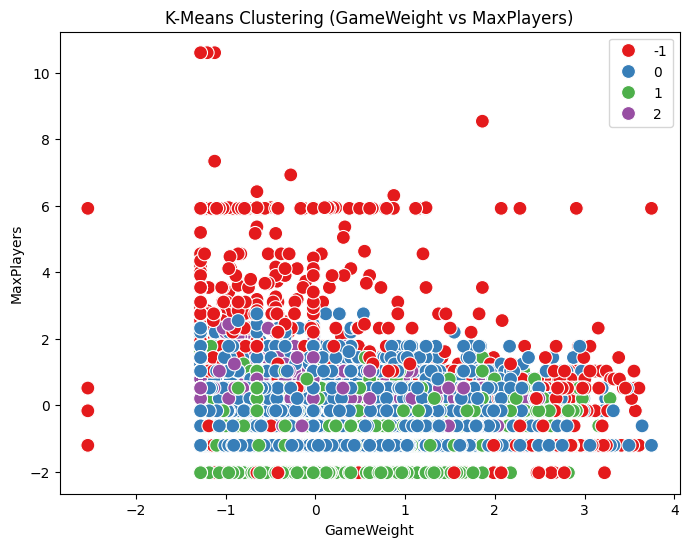

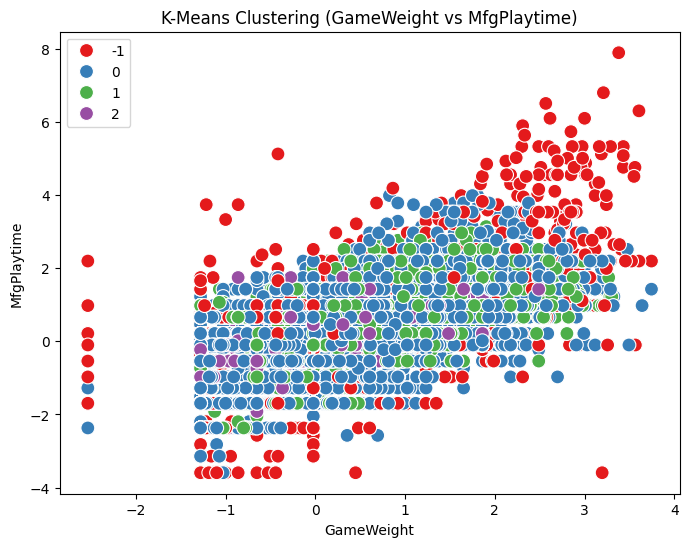

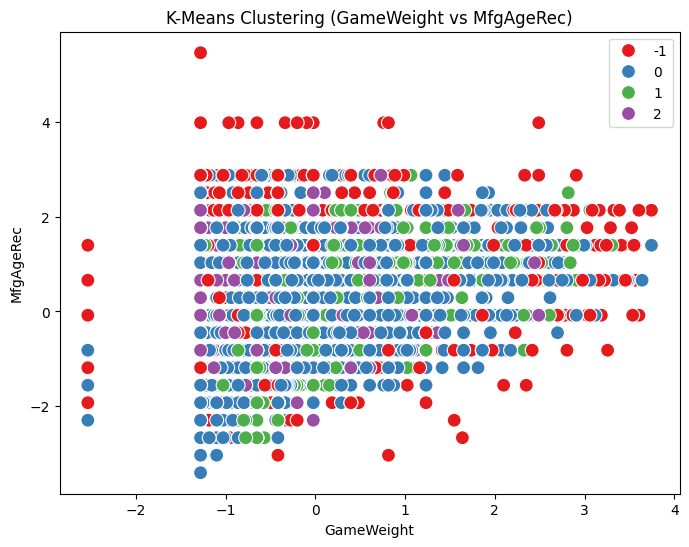

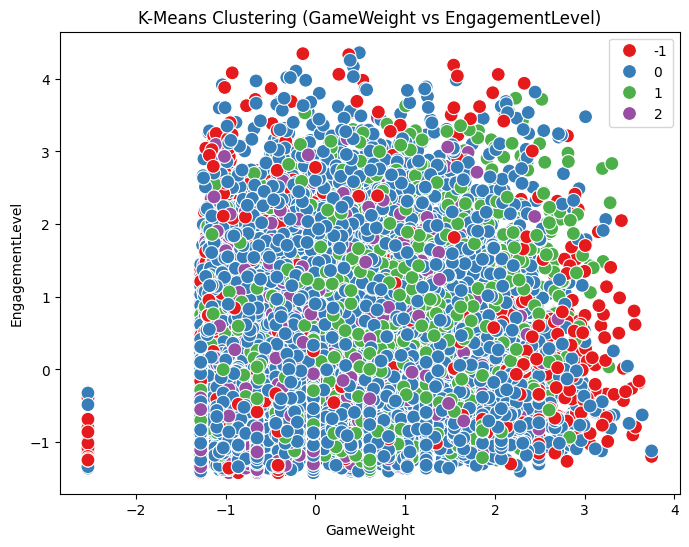

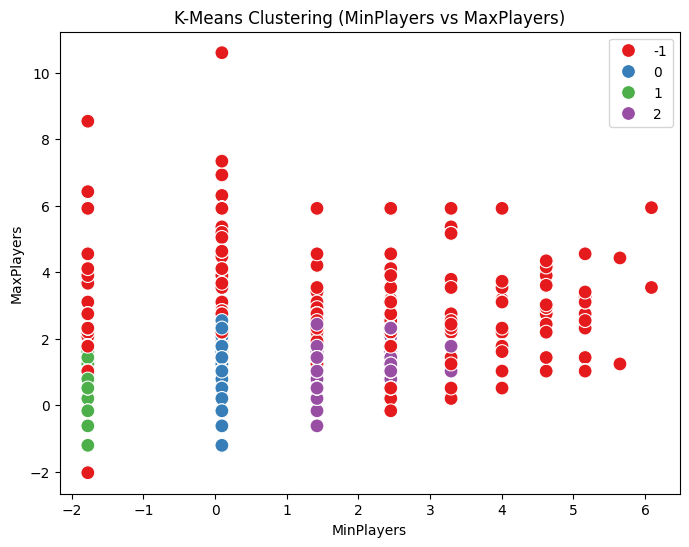

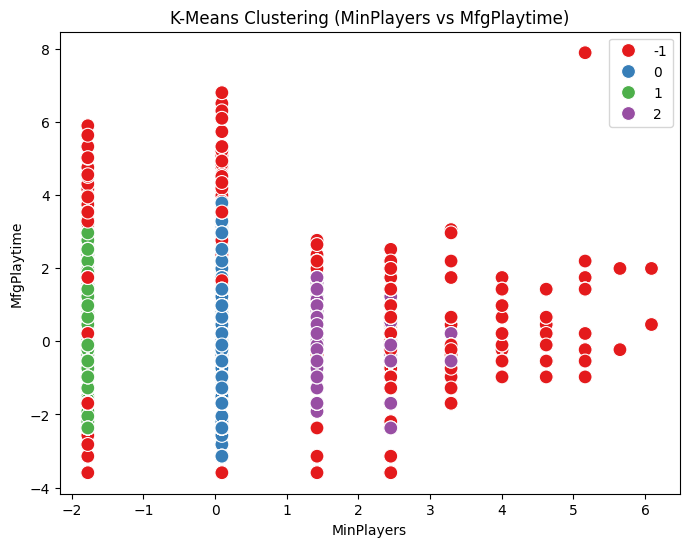

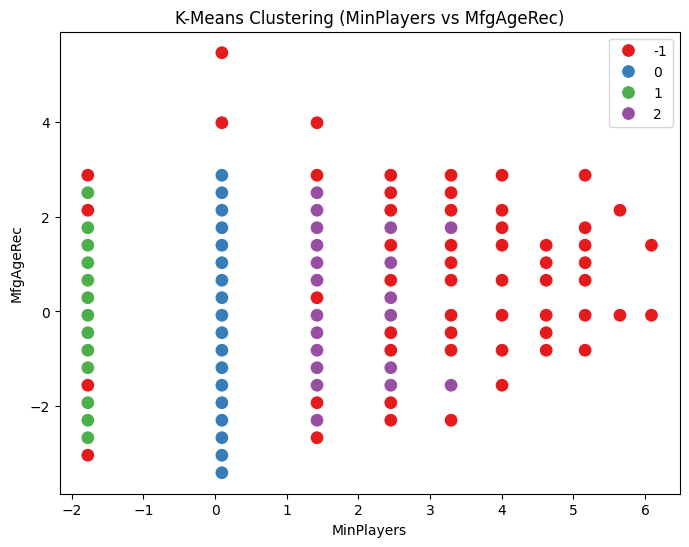

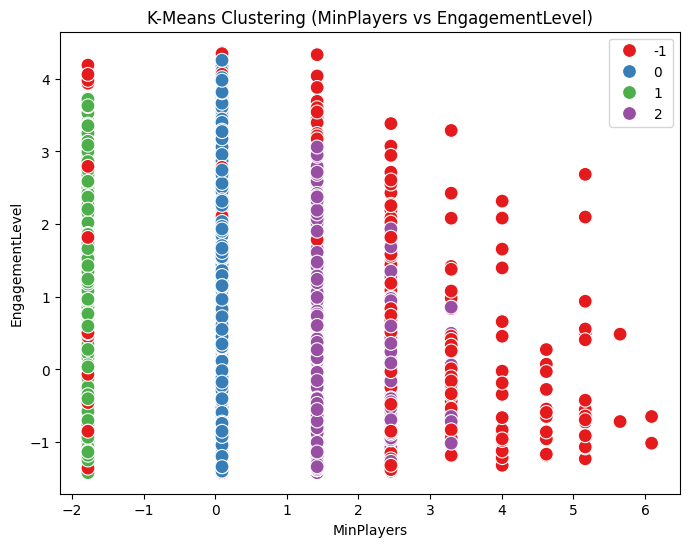

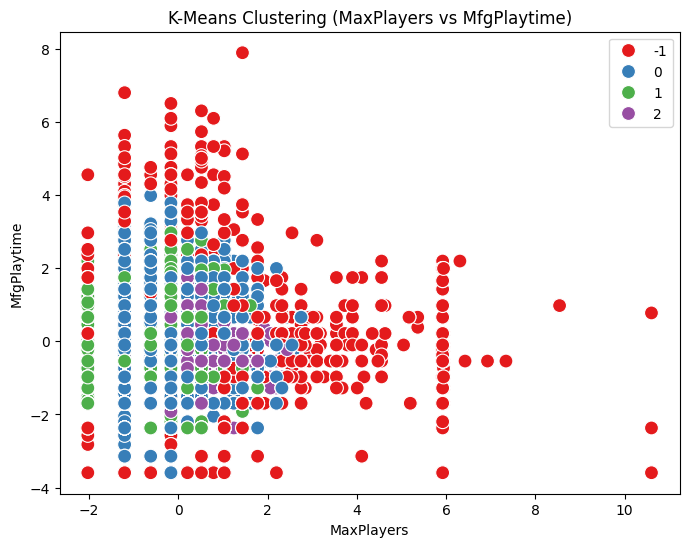

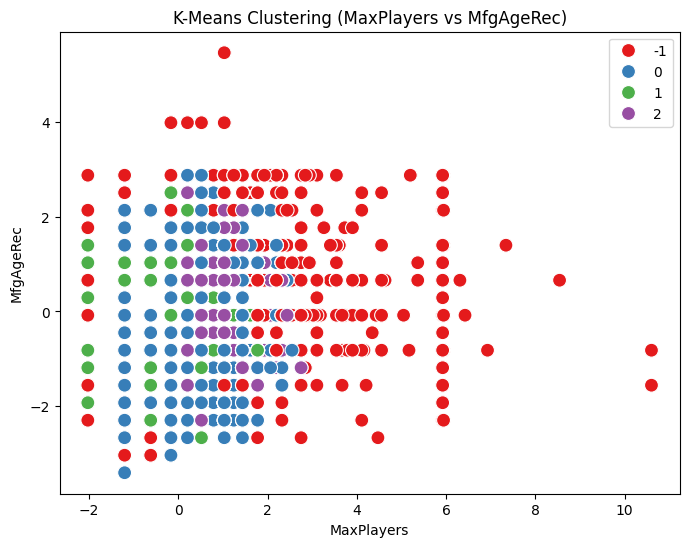

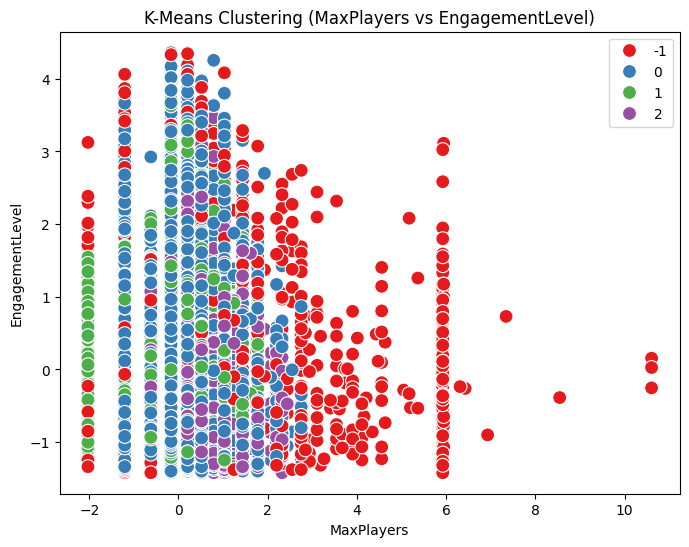

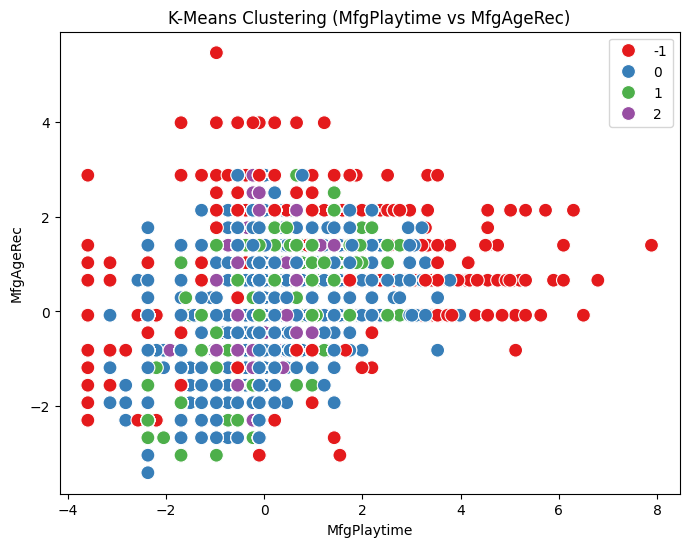

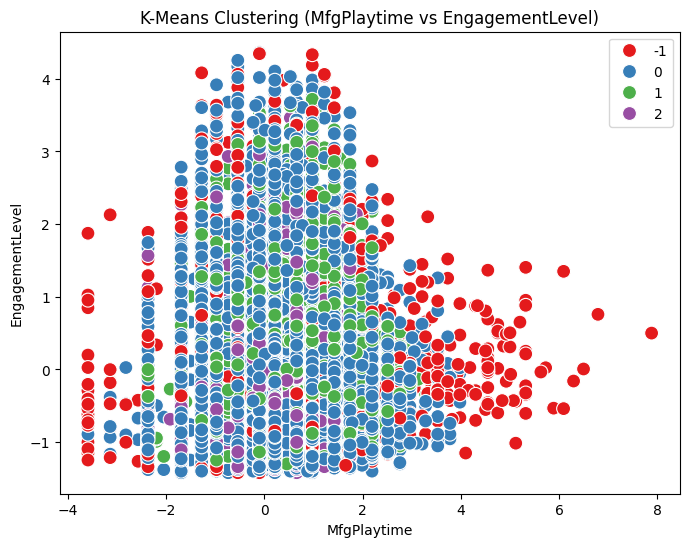

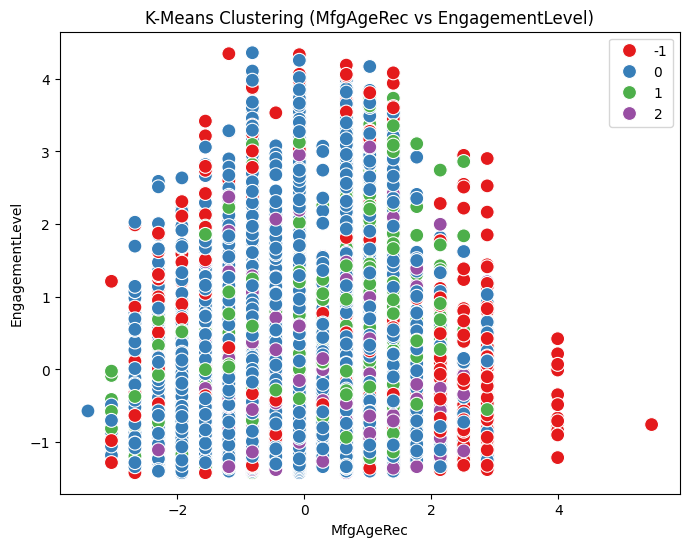

C:\Users\leona\AppData\Local\Temp\ipykernel_25704\3145122461.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


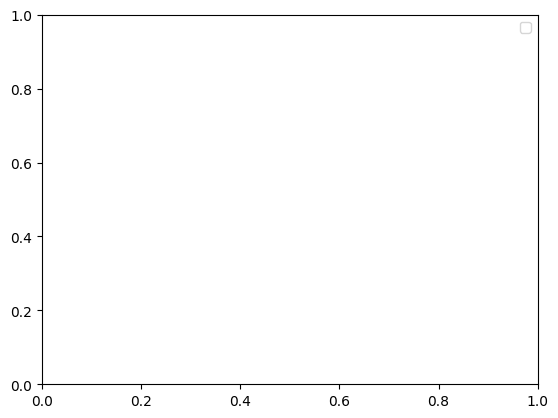

In [ ]:
labels = dbscan.labels_

mapping_features = df_num.columns.tolist()
plt.figure(figsize=(10, 6))
for i in range(X_scaled.shape[1]):
    for j in range(i + 1, X_scaled.shape[1]):
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=X_scaled[:, i], y=X_scaled[:, j], hue=labels, palette='Set1', s=100)
        #plt.scatter(centroids[:, i], centroids[:, j], c='black', s=100, marker='X', label='Centroids')
        plt.title(f'K-Means Clustering ({mapping_features[i]} vs {mapping_features[j]})')
        plt.xlabel(f'{mapping_features[i]}')
        plt.ylabel(f'{mapping_features[j]}')
        plt.legend()
        plt.show()
plt.legend()
plt.show()

(21879, 7)
21879
Inverting log transformations for readability...

--- Cluster Summary (Mean Values) ---


Cluster,-1,0,1,2
YearPublished,2007.50,2010.00,2016.00,2011.00
GameWeight,1.69,1.93,2.22,1.68
MinPlayers,2.00,2.00,1.00,3.00
MaxPlayers,7.00,4.00,4.00,6.00
MfgPlaytime,45.00,45.00,60.00,45.00
MfgAgeRec,10.00,10.00,12.00,10.00
EngagementLevel,4.37,4.38,4.84,4.43
Count,1412.00,14503.00,3346.00,2618.00
% Total,6.45,66.29,15.29,11.97


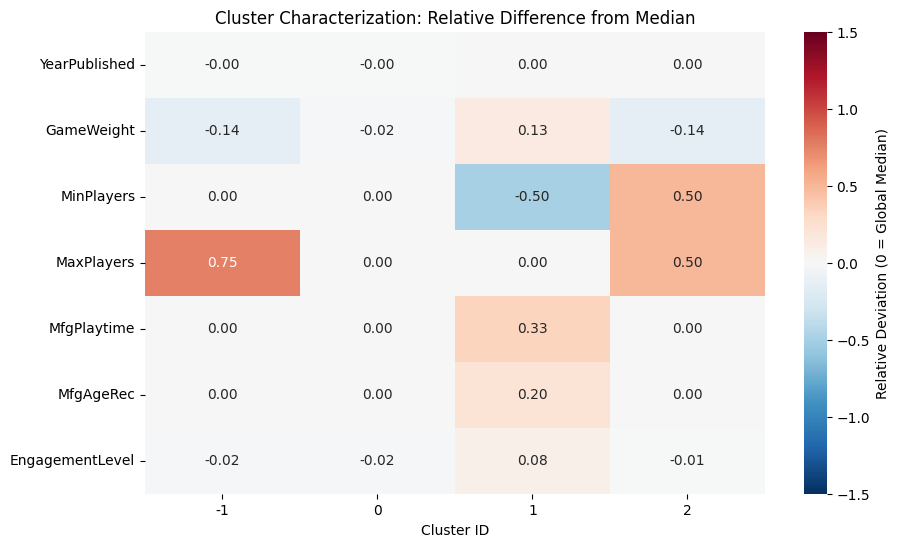

C:\Users\leona\AppData\Local\Temp\ipykernel_33852\1041056533.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df_analysis, ax=axes[i], palette='tab10')
C:\Users\leona\AppData\Local\Temp\ipykernel_33852\1041056533.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df_analysis, ax=axes[i], palette='tab10')
C:\Users\leona\AppData\Local\Temp\ipykernel_33852\1041056533.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df_analysis, ax=axes[i], palette='tab10')
C:\U

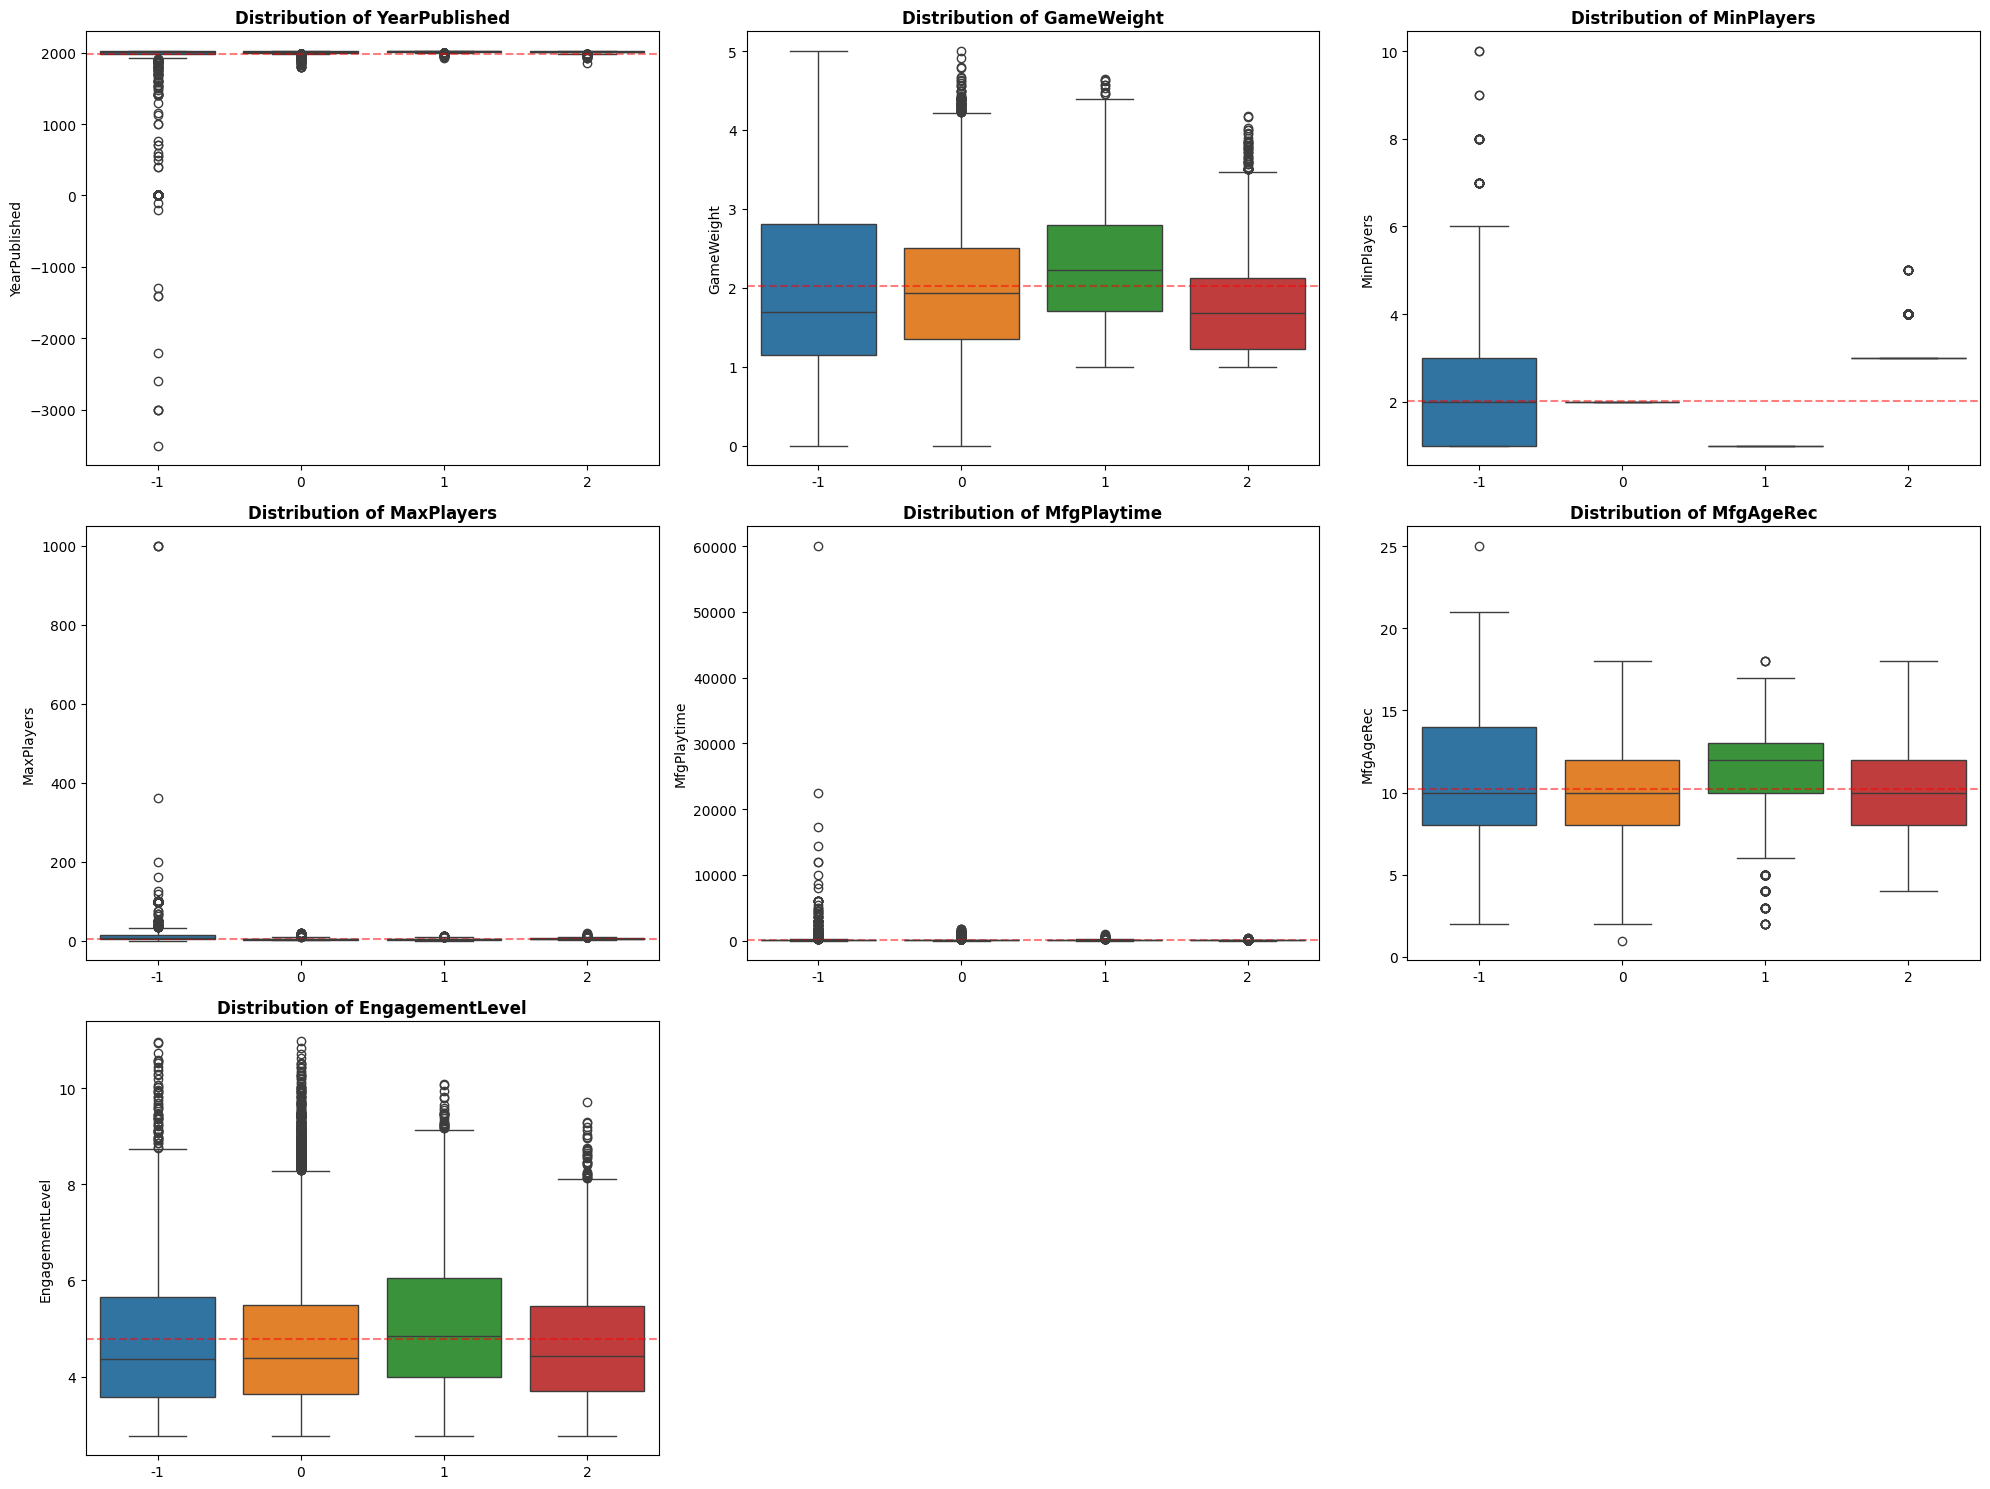


--- Analysis for Cluster -1 ---


,count,mean,std,min,25%,50%,75%,max
YearPublished,1412.0,1674.65,771.45,-3500.00,1977.00,2007.50,2016.00,2021.00
GameWeight,1412.0,2.07,1.12,0.00,1.15,1.69,2.81,5.00
MinPlayers,1412.0,2.43,1.47,1.00,1.00,2.00,3.00,10.00
MaxPlayers,1412.0,22.73,55.82,1.00,4.00,7.00,16.00,999.00
MfgPlaytime,1412.0,375.82,2035.88,1.00,20.00,45.00,120.00,60000.00
MfgAgeRec,1412.0,11.20,3.89,2.00,8.00,10.00,14.00,25.00
EngagementLevel,1412.0,4.85,1.67,2.77,3.58,4.37,5.65,10.96



--- Analysis for Cluster 0 ---


,count,mean,std,min,25%,50%,75%,max
YearPublished,14503.0,2005.52,15.40,1800.00,2000.00,2010.00,2016.0,2021.00
GameWeight,14503.0,2.00,0.77,0.00,1.35,1.93,2.5,5.00
MinPlayers,14503.0,2.00,0.00,2.00,2.00,2.00,2.0,2.00
MaxPlayers,14503.0,4.38,2.01,2.00,3.00,4.00,6.0,20.00
MfgPlaytime,14503.0,72.21,98.88,1.00,30.00,45.00,90.0,1800.00
MfgAgeRec,14503.0,9.92,2.61,1.00,8.00,10.00,12.0,18.00
EngagementLevel,14503.0,4.72,1.40,2.77,3.64,4.38,5.5,10.98



--- Analysis for Cluster 1 ---


,count,mean,std,min,25%,50%,75%,max
YearPublished,3346.0,2011.88,11.50,1930.00,2010.0,2016.00,2019.00,2021.00
GameWeight,3346.0,2.28,0.77,1.00,1.7,2.22,2.80,4.65
MinPlayers,3346.0,1.00,0.00,1.00,1.0,1.00,1.00,1.00
MaxPlayers,3346.0,4.00,1.86,1.00,2.0,4.00,5.00,12.00
MfgPlaytime,3346.0,87.75,86.95,5.00,30.0,60.00,120.00,960.00
MfgAgeRec,3346.0,10.93,2.55,2.00,10.0,12.00,13.00,18.00
EngagementLevel,3346.0,5.12,1.43,2.77,4.0,4.84,6.05,10.09



--- Analysis for Cluster 2 ---


,count,mean,std,min,25%,50%,75%,max
YearPublished,2618.0,2008.06,10.92,1860.00,2003.00,2011.00,2016.00,2021.00
GameWeight,2618.0,1.77,0.65,1.00,1.22,1.68,2.12,4.18
MinPlayers,2618.0,3.13,0.35,3.00,3.00,3.00,3.00,5.00
MaxPlayers,2618.0,6.27,1.98,3.00,5.00,6.00,7.00,20.00
MfgPlaytime,2618.0,53.50,40.34,5.00,30.00,45.00,60.00,360.00
MfgAgeRec,2618.0,10.37,2.30,4.00,8.00,10.00,12.00,18.00
EngagementLevel,2618.0,4.70,1.29,2.77,3.70,4.43,5.47,9.71


In [11]:
# --- 1. Preparazione dei Dati per l'Analisi ---
# Copiamo il dataset filtrato per non sporcare l'originale
labels = dbscan.labels_
df_analysis = df_num.copy()
print(df_analysis.shape)
# Aggiungiamo le etichette dei cluster trovati
# Assicurati che 'kmeans' sia il tuo modello fittato e 'X_final' i dati usati
print(len(labels))
df_analysis['Cluster'] = labels

# --- IMPORTANTE: Inversione delle trasformazioni ---
# Per interpretare i dati, dobbiamo tornare ai valori originali (non logaritmici)
# Se hai la lista 'log_cols' dal tuo codice precedente:
if 'log_cols' in locals():
    print("Inverting log transformations for readability...")
    for col in log_cols:
        if col in df_analysis.columns:
            # Applichiamo expm1 (inverso di log1p)
            df_analysis[col] = np.expm1(df_analysis[col])

# ritraformazione di YearPublished in 'Anno' invece di 'Recency'
if 'YearPublished' in df_analysis.columns:
    df_analysis['YearPublished'] = df['YearPublished'].max() - df_analysis['YearPublished']

# --- 2. Tabella Riassuntiva (Centroidi Reali) ---
# Calcoliamo la mediana di ogni feature per ogni cluster
cluster_medians = df_analysis.groupby('Cluster').median()
cluster_counts = df_analysis['Cluster'].value_counts().sort_index()

# Aggiungiamo la dimensione del cluster per contesto
cluster_summary = cluster_medians.copy()
cluster_summary['Count'] = cluster_counts
cluster_summary['% Total'] = (cluster_counts / len(df_analysis)) * 100

print("\n--- Cluster Summary (Mean Values) ---")
# Trasponiamo per leggere meglio se hai tante colonne
display(cluster_summary.T.round(2))


# --- 3. Heatmap delle Differenze Relative (Profilazione) ---
# Questa visualizzazione risponde a: "In cosa questo cluster è diverso dalla mediana globale?"
# Rosso = Molto sopra la mediana, Blu = Molto sotto la mediana

global_median = df_analysis.drop(columns=['Cluster']).median()
# Calcoliamo la deviazione percentuale dalla mediana globale
relative_imp = (cluster_medians - global_median) / global_median

plt.figure(figsize=(10, 6))
sns.heatmap(data=relative_imp.T, 
            cmap='RdBu_r', 
            center=0, 
            annot=True, 
            fmt=".2f",
            vmax=1.5, vmin=-1.5, # Limita i colori estremi per leggibilità
            cbar_kws={'label': 'Relative Deviation (0 = Global Median)'})
plt.title('Cluster Characterization: Relative Difference from Median')
plt.xlabel('Cluster ID')
plt.show()


# --- 4. Boxplots Dettagliati (Distribuzione) ---
# I boxplot sono fondamentali per vedere se un cluster è "compatto" o "disperso"
# Creiamo un grafico per ogni feature numerica

features_to_plot = [col for col in df_analysis.columns if col not in ['Cluster']]
n_features = len(features_to_plot)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.boxplot(x='Cluster', y=col, data=df_analysis, ax=axes[i], palette='tab10')
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    
    # Linea tratteggiata rossa per la media globale
    global_avg = df_analysis[col].mean()
    axes[i].axhline(global_avg, color='red', linestyle='--', alpha=0.5, label='Global Avg')

# Rimuovi assi vuoti se ce ne sono
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# --- 5. Analisi divisa per Cluster ---
for cluster_id in sorted(df_analysis['Cluster'].unique()):
    print(f"\n--- Analysis for Cluster {cluster_id} ---")
    cluster_data = df_analysis[df_analysis['Cluster'] == cluster_id]
    # display statistics without the Cluster column
    display(cluster_data.drop(columns=['Cluster']).describe().T.round(2))

In [12]:
# check if clusters match some categorical features
# --- IGNORE ---
for i in range(len(set(labels))):
    cluster = np.where(labels == i)[0]
    cluster_indices = cluster
    cluster_data = df.iloc[cluster_indices]
    print(f"Cluster {i}:")
    print(f" Number of items: {len(cluster_data)}")
    for col in ['HasFamily', 'Category', 'Rating', 'Kickstarted', 'IsReimplementation','Rank','NumImplementations','NumExpansions','NumAlternates']:
        if col == 'Rank':
            median_rank = cluster_data[col].median()
            print(f"  Median {col}: {median_rank}")
            continue
        if col == 'NumImplementations':
            median_imp= cluster_data[col].median()
            print(f"  Median {col}: {median_imp}")
            continue
        if col == 'NumExpansions':
            median_exp = cluster_data[col].median()
            print(f"  Median {col}: {median_exp}")
            continue
        if col == 'NumAlternates':
            median_alt = cluster_data[col].median()
            print(f"  Median {col}: {median_alt}")
            continue
        
        value_counts = cluster_data[col].value_counts(normalize=True) * 100
        print(f"  {col} distribution:")
        print(value_counts)
    print("\n")   

Cluster 0:
 Number of items: 14503
  HasFamily distribution:
HasFamily
0    70.047576
1    29.952424
Name: proportion, dtype: float64
  Category distribution:
Category
NoCategory    49.086396
War           16.451769
Family         9.115355
Strategy       6.708957
Abstract       6.033235
Childrens      5.026546
Thematic       3.999173
CGS            1.875474
Party          1.703096
Name: proportion, dtype: float64
  Rating distribution:
Rating
Medium    44.177067
Low       36.068400
High      19.754534
Name: proportion, dtype: float64
  Kickstarted distribution:
Kickstarted
0    87.050955
1    12.949045
Name: proportion, dtype: float64
  IsReimplementation distribution:
IsReimplementation
0    88.664414
1    11.335586
Name: proportion, dtype: float64
  Median Rank: 3363.0
  Median NumImplementations: 0.0
  Median NumExpansions: 0.0
  Median NumAlternates: 0.0


Cluster 1:
 Number of items: 3346
  HasFamily distribution:
HasFamily
0    64.734011
1    35.265989
Name: proportion, dtype: fl

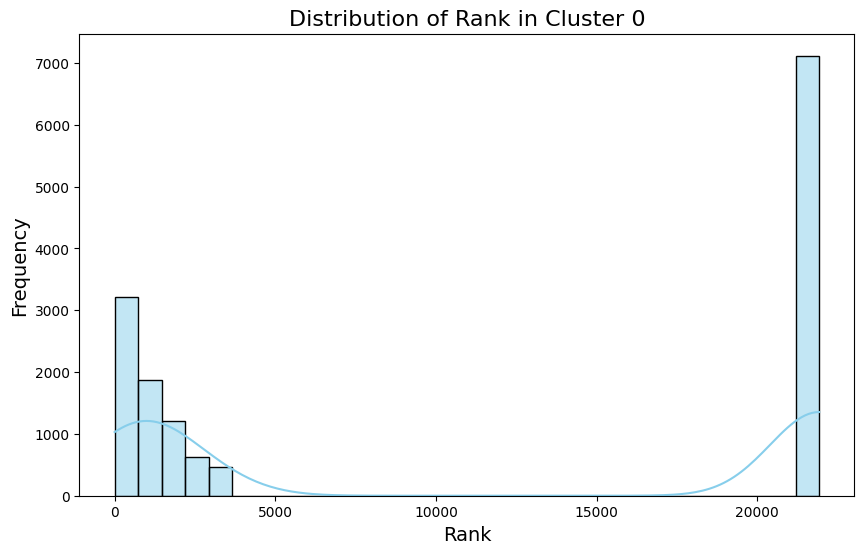

In [17]:
# studying cluster 0 distribution of rank
cluster = np.where(labels == 0)[0]
cluster_indices = cluster
cluster_data = df.iloc[cluster_indices]
cluster_0 = cluster_data[['Rank']]
# plot rank distribution
plt.figure(figsize=(10, 6))
sns.histplot(cluster_0['Rank'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Rank in Cluster 0', fontsize=16)
plt.xlabel('Rank', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.show()


# OPTICS

In [169]:
from sklearn.cluster import OPTICS, cluster_optics_dbscan

OPTICS with min_samples = 4


C:\Users\leona\AppData\Local\Temp\ipykernel_25704\3146178100.py:11: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.
  plt.plot(space, reachability, "k.", alpha=0.4, color='mediumblue')


OPTICS with min_samples = 8


C:\Users\leona\AppData\Local\Temp\ipykernel_25704\3146178100.py:11: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.
  plt.plot(space, reachability, "k.", alpha=0.4, color='mediumblue')


OPTICS with min_samples = 16


C:\Users\leona\AppData\Local\Temp\ipykernel_25704\3146178100.py:11: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.
  plt.plot(space, reachability, "k.", alpha=0.4, color='mediumblue')


OPTICS with min_samples = 32


C:\Users\leona\AppData\Local\Temp\ipykernel_25704\3146178100.py:11: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.
  plt.plot(space, reachability, "k.", alpha=0.4, color='mediumblue')


OPTICS with min_samples = 64


C:\Users\leona\AppData\Local\Temp\ipykernel_25704\3146178100.py:11: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.
  plt.plot(space, reachability, "k.", alpha=0.4, color='mediumblue')


OPTICS with min_samples = 128


C:\Users\leona\AppData\Local\Temp\ipykernel_25704\3146178100.py:11: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.
  plt.plot(space, reachability, "k.", alpha=0.4, color='mediumblue')


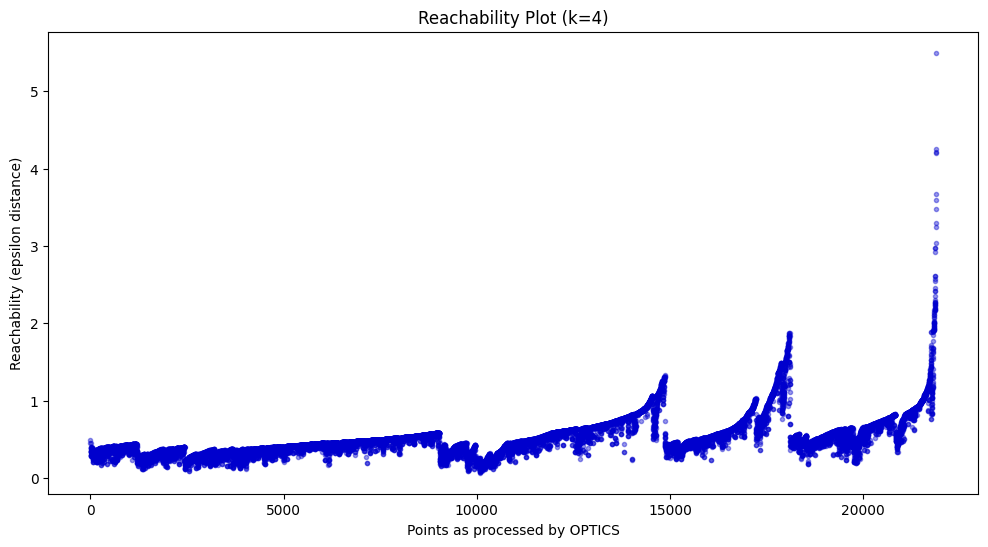

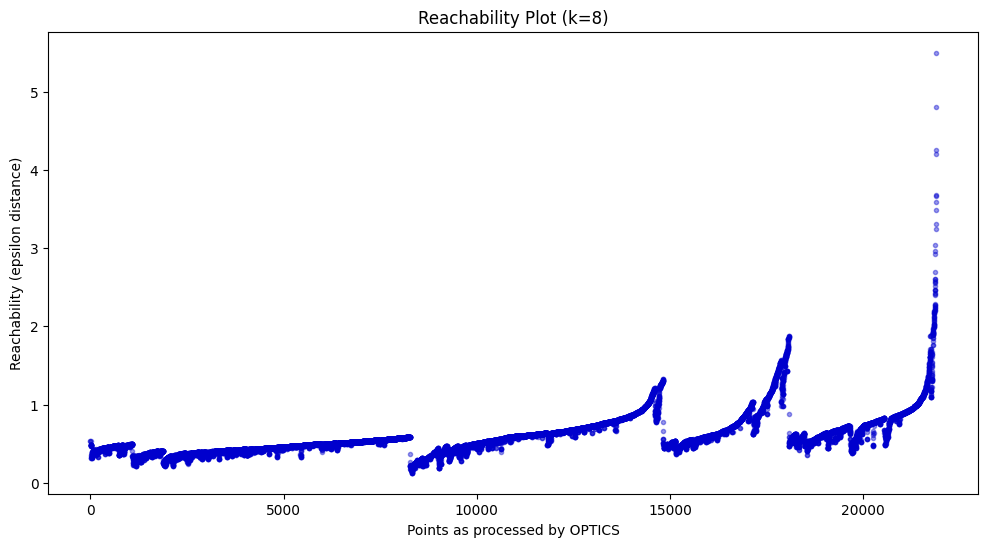

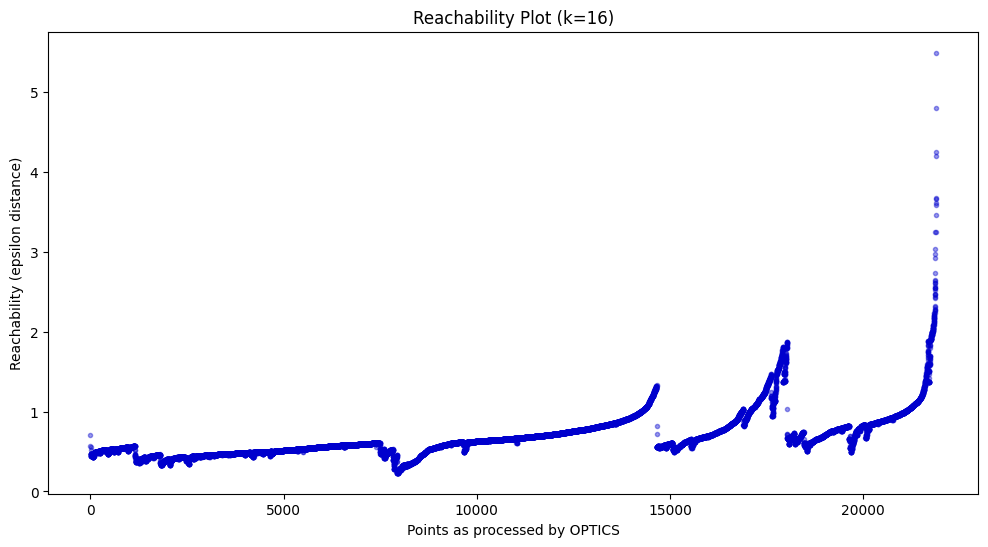

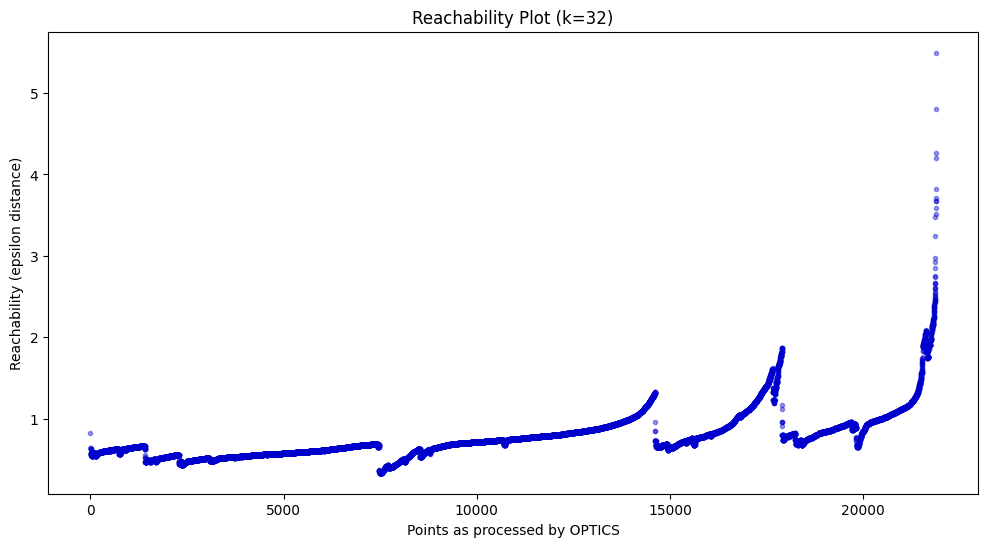

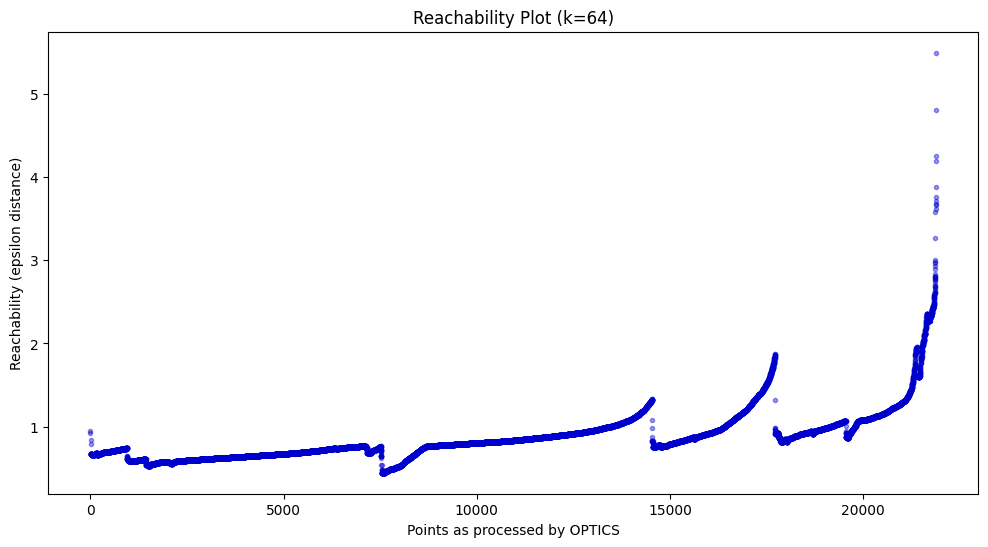

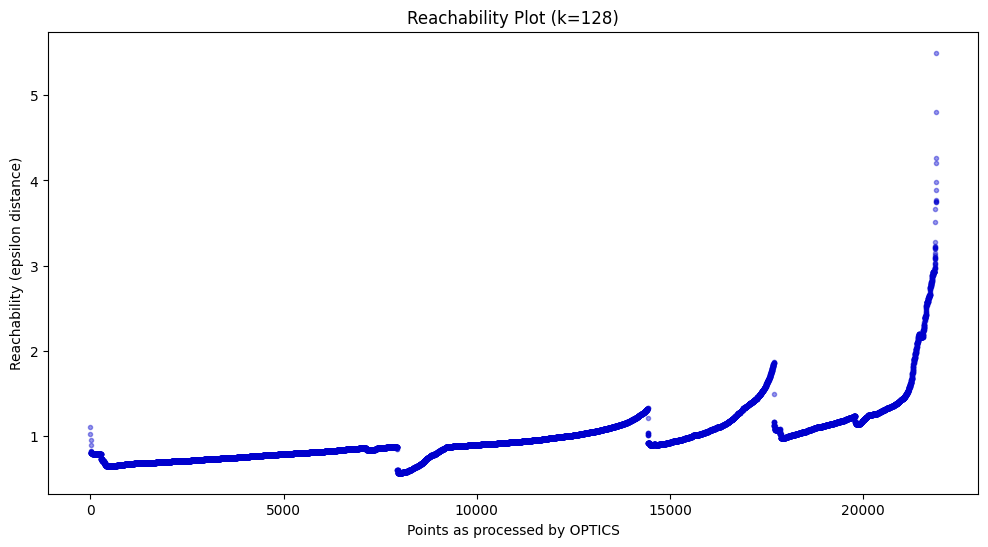

In [178]:
for min_samples in [4, 8, 16, 32, 64, 128]:
    print('OPTICS with min_samples =', min_samples)
    optics = OPTICS(min_samples=min_samples, min_cluster_size=40, metric='euclidean', eps=np.inf)
    optics.fit(X_scaled)
    space = np.arange(len(X_scaled))
    reachability = optics.reachability_[optics.ordering_]
    labels = optics.labels_[optics.ordering_]

    # Reachability plot
    plt.figure(figsize=(12, 6))
    plt.plot(space, reachability, "k.", alpha=0.4, color='mediumblue')
    plt.xlabel("Points as processed by OPTICS")
    plt.ylabel("Reachability (epsilon distance)")
    # plt.axhline(0.3, c="red")
    plt.title("Reachability Plot (k={})".format(min_samples))

In [192]:
# Range di MinPts che hai scelto
min_samples_range = [4, 8, 16, 32, 64, 128]
results = []

print(f"{'MinPts':<10} {'Best Eps':<10} {'Clusters':<10} {'Cluster sizes':<20} {'Noise %':<10} {'Silhouette':<10}")
print("-" * 80)

for min_pts in min_samples_range:
    # Definisci un range di taglio sensato guardando il tuo grafico (es. da 1.0 a 1.8)
    eps_candidates = np.arange(1.0, 1.8, 0.1)
    
    for eps in eps_candidates:
        best_sil_local = -1
        best_eps_local = -1
        best_labels = None
        # 1. Fit OPTICS (max_eps=inf per vedere tutto)
        optics = OPTICS(min_samples=min_pts, max_eps=eps, metric='euclidean', min_cluster_size=40, xi=0.07)
        optics.fit(X_scaled)
        
        labels = optics.labels_

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        # Filtri di validità: almeno 3 cluster (visto che vedi 3 valli) e rumore < 50%
        if n_clusters >= 3 and n_noise < len(labels) * 0.5:
            sil = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
            if sil > best_sil_local:
                best_sil_local = sil
                best_eps_local = eps
                best_labels = labels
                best_cluster_sizes = np.bincount(labels[labels != -1])
    
        # Se abbiamo trovato una configurazione valida
        if best_labels is not None:
            noise_perc = (list(best_labels).count(-1) / len(best_labels)) * 100
            n_clusters_final = len(set(best_labels)) - 1
            
            print(f"{min_pts:<10} {best_eps_local:<10.1f} {n_clusters_final:<10}  {str(best_cluster_sizes):<20} {noise_perc:>6.1f}% {best_sil_local:>10.3f}")
            
            results.append({
                'min_pts': min_pts,
                'epsilon': best_eps_local,
                'silhouette': best_sil_local,
                'noise': noise_perc,
                'cluster_sizes': best_cluster_sizes
            })
        else:
            print(f"{min_pts:<10} {'N/A':<10} {'-':<10} {'-':<20} {'Valid Cut Not Found'}")

MinPts     Best Eps   Clusters   Cluster sizes        Noise %    Silhouette
--------------------------------------------------------------------------------
4          1.0        5           [14483  3411  2339   360   114]    5.4%      0.086
4          1.1        3           [14711  3508  2801]     3.9%      0.114
4          1.2        3           [14771  3583  2875]     3.0%      0.117
4          1.3        3           [14853  3619  2923]     2.2%      0.118
4          1.4        4           [17838  3632    42    94]    1.2%      0.196
4          N/A        -          -                    Valid Cut Not Found
4          N/A        -          -                    Valid Cut Not Found
4          N/A        -          -                    Valid Cut Not Found
8          1.0        5           [14408  3315  2288   291    50]    7.0%      0.078
8          1.1        4           [14519  3465  2724   115]    4.8%      0.117
8          1.2        4           [14593  3544  2831   126]    3.6%    

Scelta dell'epsilon finale

In [218]:
optics = OPTICS(min_samples = 4, max_eps = 0.5, min_cluster_size=1000, xi=0.05)
optics.fit(X_scaled)

,min_samples,4
,max_eps,0.5
,metric,'minkowski'
,p,2
,metric_params,None
,cluster_method,'xi'
,eps,None
,xi,0.05
,predecessor_correction,True
,min_cluster_size,1000
,algorithm,'auto'


In [219]:
print("Cluster sizes:", np.bincount(optics.labels_[optics.labels_ != -1]))

Cluster sizes: [7623 2409]


In [220]:
print("Silhouette", silhouette_score(X_scaled[optics.labels_ != -1], optics.labels_[optics.labels_ != -1]))

Silhouette 0.18338229394489874


In [221]:
print("Noise:", list(optics.labels_).count(-1))

Noise: 11847


C:\Users\leona\AppData\Local\Temp\ipykernel_25704\1749980298.py:8: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.
  plt.plot(space, reachability, "k.", alpha=0.4, color='mediumblue')


Text(0.5, 1.0, 'Reachability Plot')

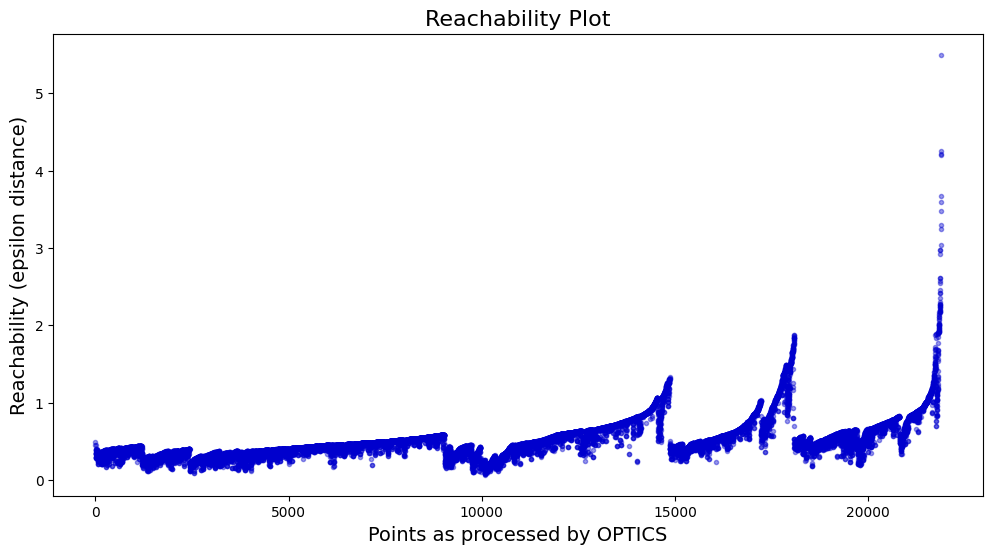

In [196]:
# Valleys in the plot correspond to the clusters
space = np.arange(len(X_scaled))
reachability = optics.reachability_[optics.ordering_]
labels = optics.labels_[optics.ordering_]

# Reachability plot
plt.figure(figsize=(12, 6))
plt.plot(space, reachability, "k.", alpha=0.4, color='mediumblue')
plt.xlabel("Points as processed by OPTICS", fontsize=14)
plt.ylabel("Reachability (epsilon distance)", fontsize=14)
# plt.axhline(0.3, c="red")
plt.title("Reachability Plot", fontsize=16)

C:\Users\leona\AppData\Local\Temp\ipykernel_25704\3628301535.py:8: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.
  plt.plot(space, reachability, "k.", alpha=0.4, color='mediumblue')


Text(0.5, 1.0, 'Reachability Plot (k = 4)')

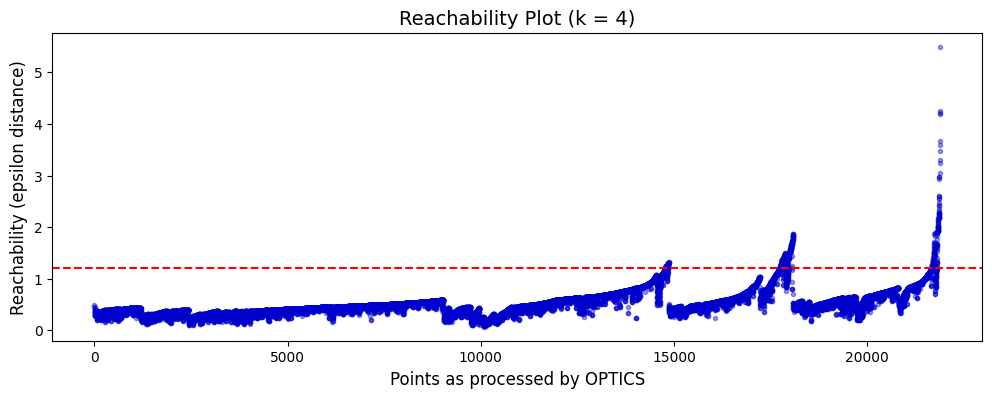

In [199]:
# Valleys in the plot correspond to the clusters
space = np.arange(len(X_scaled))
reachability = optics.reachability_[optics.ordering_]
labels = optics.labels_[optics.ordering_]

# Reachability plot + redline for eps cutoff
plt.figure(figsize=(12, 4))
plt.plot(space, reachability, "k.", alpha=0.4, color='mediumblue')
plt.axhline(1.2, c="red", linestyle='--', label='eps cutoff = 1.3')
plt.xlabel("Points as processed by OPTICS", fontsize=12)
plt.ylabel("Reachability (epsilon distance)", fontsize=12)
# plt.axhline(0.3, c="red")
plt.title("Reachability Plot (k = 4)", fontsize=14)

C:\Users\leona\AppData\Local\Temp\ipykernel_25704\3383678403.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.
  plt.plot(space, reachability, "k.", alpha=0.4, color='mediumblue')


Text(0.5, 1.0, 'Reachability Plot')

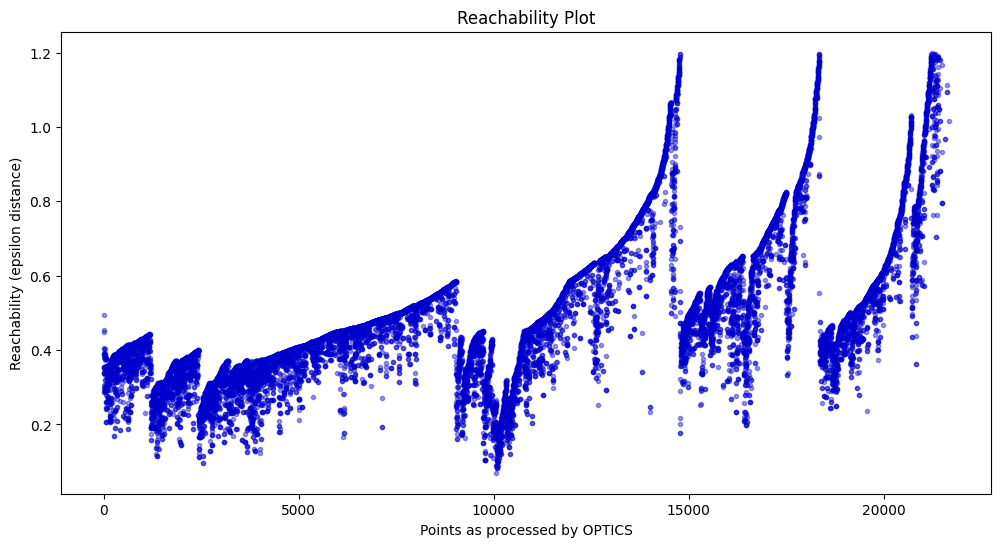

In [159]:
optics = OPTICS(min_samples = 4, max_eps = 1.2, min_cluster_size=40, xi=0.07)
optics.fit(X_scaled)
space = np.arange(len(X_scaled))
reachability = optics.reachability_[optics.ordering_]
labels = optics.labels_[optics.ordering_]

# Reachability plot + redline for eps cutoff
plt.figure(figsize=(12, 6))
plt.plot(space, reachability, "k.", alpha=0.4, color='mediumblue')
plt.xlabel("Points as processed by OPTICS")
plt.ylabel("Reachability (epsilon distance)")
# plt.axhline(0.3, c="red")
plt.title("Reachability Plot")

In [213]:
print("Silhouette", silhouette_score(X_scaled[optics.labels_ != -1], optics.labels_[optics.labels_ != -1]))

Silhouette 0.1181725182504687


(21879, 7)
21879
Inverting log transformations for readability...

--- Cluster Summary (Mean Values) ---


Cluster,-1,0,1,2
YearPublished,2009.00,2010.00,2016.00,2011.00
GameWeight,1.67,1.92,2.24,1.67
MinPlayers,2.00,2.00,1.00,3.00
MaxPlayers,19.00,4.00,4.00,6.00
MfgPlaytime,45.00,45.00,60.00,45.00
MfgAgeRec,10.00,10.00,12.00,10.00
EngagementLevel,4.34,4.38,4.82,4.44
Count,484.00,14853.00,3619.00,2923.00
% Total,2.21,67.89,16.54,13.36


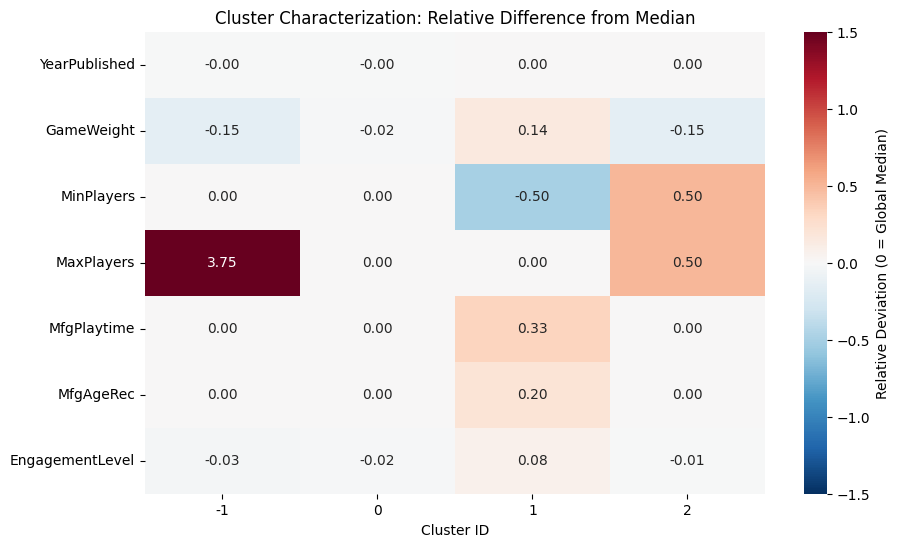

C:\Users\leona\AppData\Local\Temp\ipykernel_25704\4091376659.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df_analysis, ax=axes[i], palette='tab10')
C:\Users\leona\AppData\Local\Temp\ipykernel_25704\4091376659.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df_analysis, ax=axes[i], palette='tab10')
C:\Users\leona\AppData\Local\Temp\ipykernel_25704\4091376659.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df_analysis, ax=axes[i], palette='tab10')
C:\U

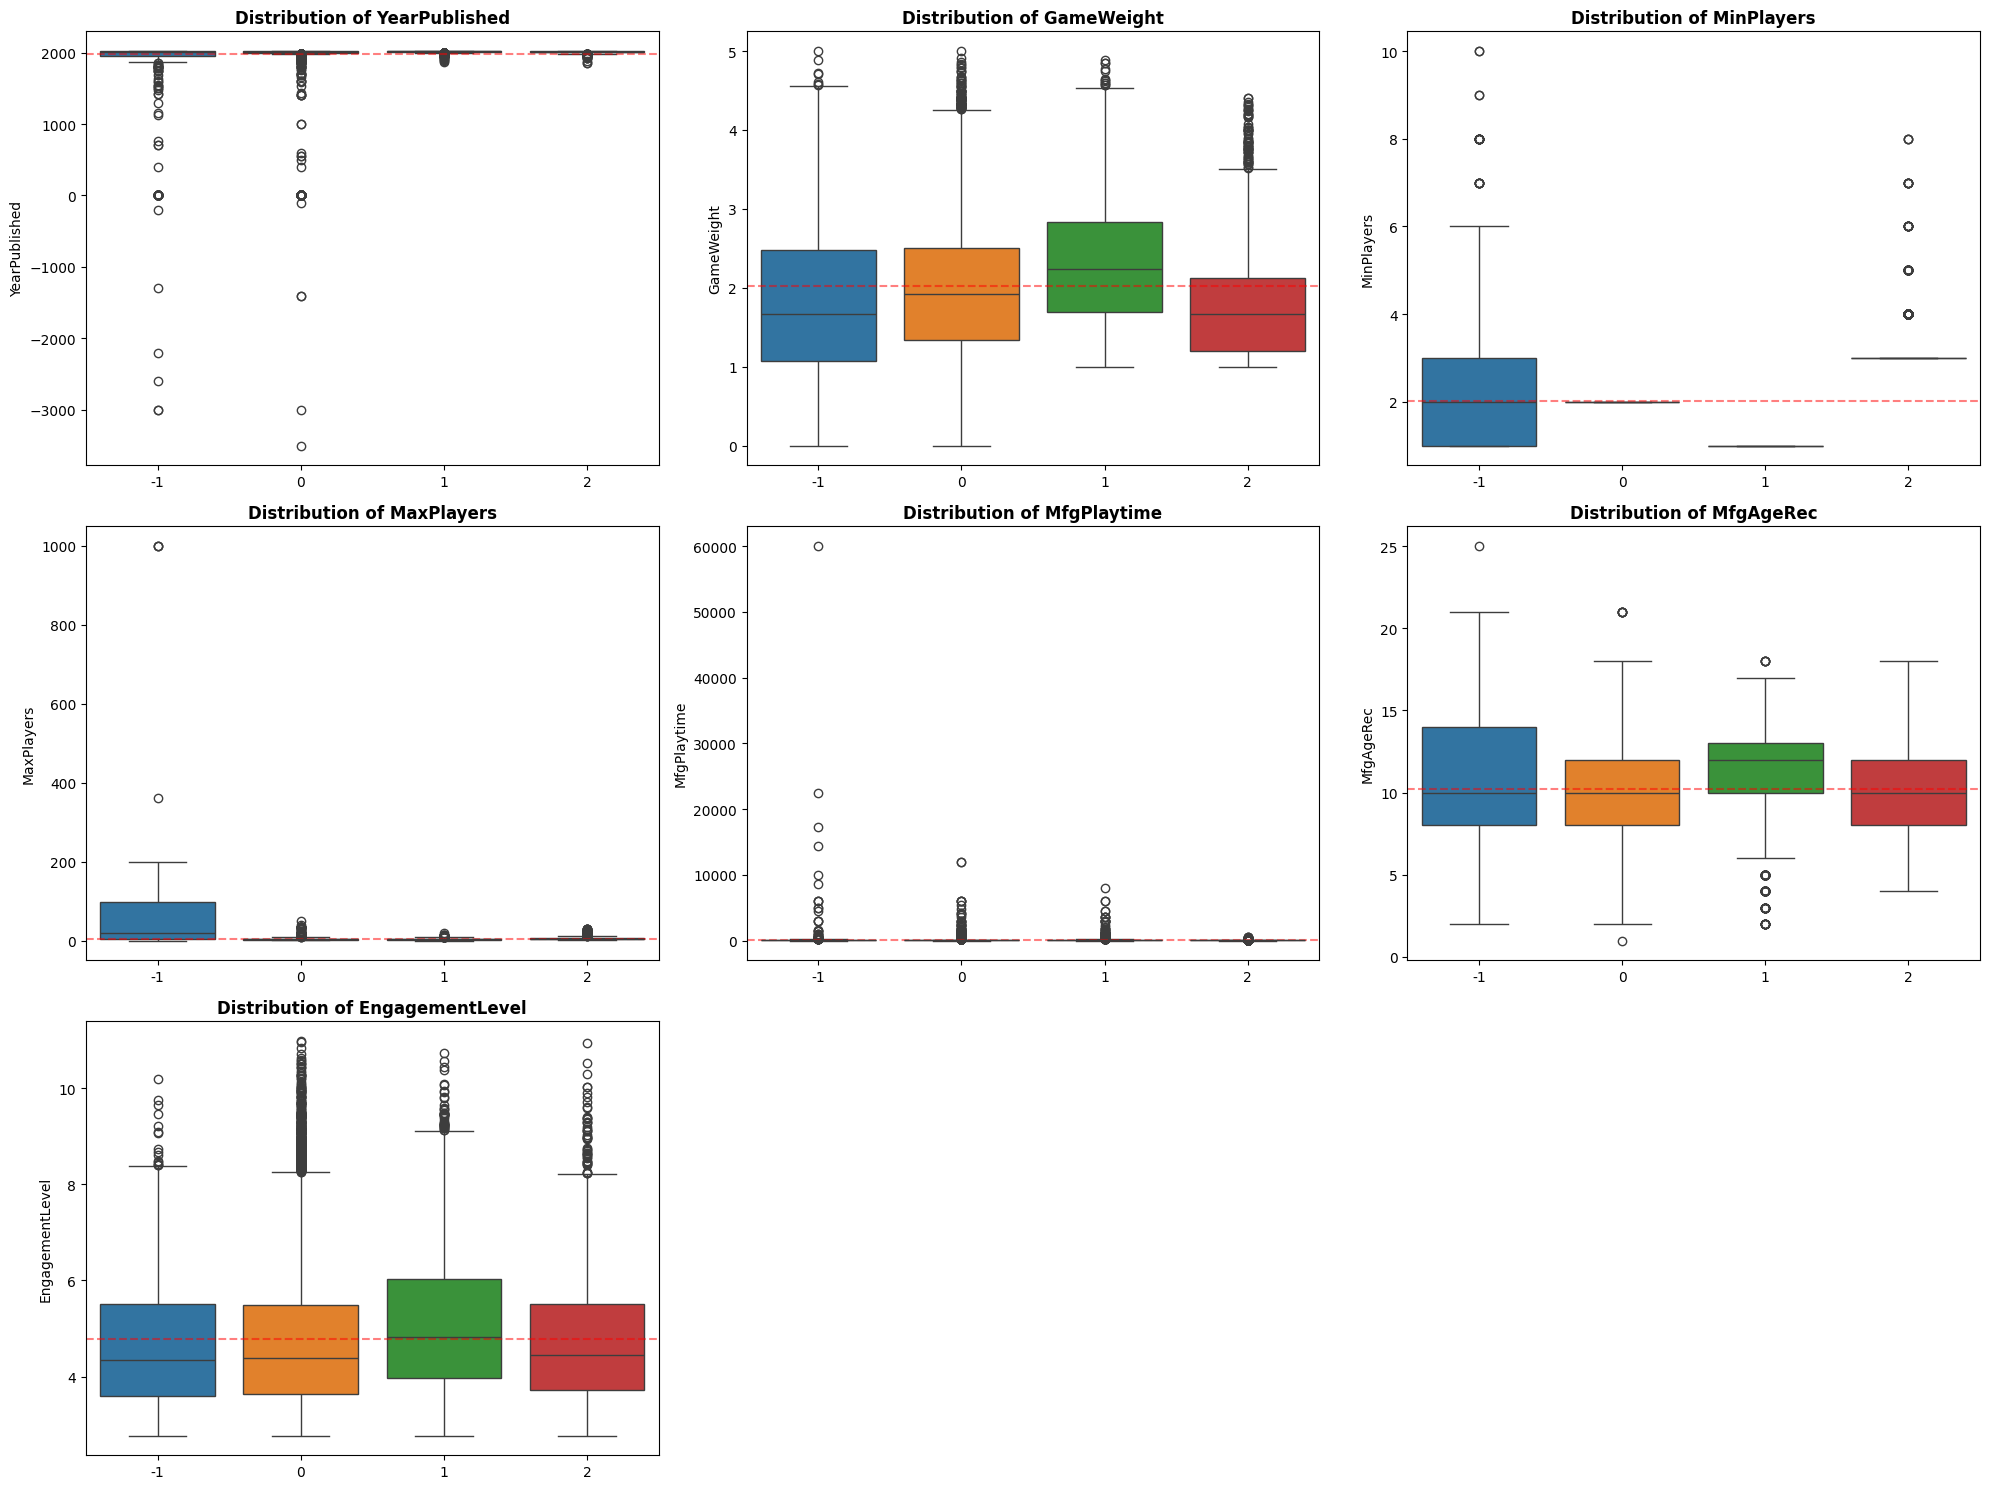


--- Analysis for Cluster -1 ---


,count,mean,std,min,25%,50%,75%,max
YearPublished,484.0,1630.19,828.26,-3000.00,1951.50,2009.00,2016.00,2021.0
GameWeight,484.0,1.91,0.99,0.00,1.08,1.67,2.48,5.0
MinPlayers,484.0,2.64,1.76,1.00,1.00,2.00,3.00,10.0
MaxPlayers,484.0,51.41,88.08,1.00,5.00,19.00,99.00,999.0
MfgPlaytime,484.0,446.30,3189.97,1.00,20.00,45.00,90.00,60000.0
MfgAgeRec,484.0,10.85,4.04,2.00,8.00,10.00,14.00,25.0
EngagementLevel,484.0,4.76,1.51,2.77,3.59,4.34,5.51,10.2



--- Analysis for Cluster 0 ---


,count,mean,std,min,25%,50%,75%,max
YearPublished,14853.0,1986.31,199.74,-3500.00,2000.00,2010.00,2016.00,2021.00
GameWeight,14853.0,2.00,0.79,0.00,1.33,1.92,2.50,5.00
MinPlayers,14853.0,2.00,0.00,2.00,2.00,2.00,2.00,2.00
MaxPlayers,14853.0,4.44,2.35,2.00,3.00,4.00,6.00,50.00
MfgPlaytime,14853.0,81.26,232.99,1.00,30.00,45.00,90.00,12000.00
MfgAgeRec,14853.0,9.94,2.64,1.00,8.00,10.00,12.00,21.00
EngagementLevel,14853.0,4.72,1.41,2.77,3.64,4.38,5.49,10.98



--- Analysis for Cluster 1 ---


,count,mean,std,min,25%,50%,75%,max
YearPublished,3619.0,2011.13,13.07,1870.00,2010.00,2016.00,2019.00,2021.00
GameWeight,3619.0,2.30,0.81,1.00,1.69,2.24,2.83,4.89
MinPlayers,3619.0,1.00,0.00,1.00,1.00,1.00,1.00,1.00
MaxPlayers,3619.0,4.04,2.04,1.00,2.00,4.00,5.00,20.00
MfgPlaytime,3619.0,116.89,309.13,2.00,30.00,60.00,120.00,7920.00
MfgAgeRec,3619.0,10.89,2.62,2.00,10.00,12.00,13.00,18.00
EngagementLevel,3619.0,5.12,1.45,2.77,3.98,4.82,6.04,10.74



--- Analysis for Cluster 2 ---


,count,mean,std,min,25%,50%,75%,max
YearPublished,2923.0,2008.02,11.59,1850.00,2003.00,2011.00,2016.00,2021.00
GameWeight,2923.0,1.77,0.69,1.00,1.20,1.67,2.12,4.41
MinPlayers,2923.0,3.20,0.51,3.00,3.00,3.00,3.00,8.00
MaxPlayers,2923.0,6.81,3.20,3.00,5.00,6.00,8.00,30.00
MfgPlaytime,2923.0,56.68,51.28,1.00,30.00,45.00,60.00,600.00
MfgAgeRec,2923.0,10.68,2.61,4.00,8.00,10.00,12.00,18.00
EngagementLevel,2923.0,4.75,1.36,2.77,3.71,4.44,5.52,10.94


In [214]:
labels = optics.labels_
# --- 1. Preparazione dei Dati per l'Analisi ---
# Copiamo il dataset filtrato per non sporcare l'originale
df_analysis = df_num.copy()
print(df_analysis.shape)
# Aggiungiamo le etichette dei cluster trovati
# Assicurati che 'kmeans' sia il tuo modello fittato e 'X_final' i dati usati
print(len(labels))
df_analysis['Cluster'] = labels

# --- IMPORTANTE: Inversione delle trasformazioni ---
# Per interpretare i dati, dobbiamo tornare ai valori originali (non logaritmici)
# Se hai la lista 'log_cols' dal tuo codice precedente:
if 'log_cols' in locals():
    print("Inverting log transformations for readability...")
    for col in log_cols:
        if col in df_analysis.columns:
            # Applichiamo expm1 (inverso di log1p)
            df_analysis[col] = np.expm1(df_analysis[col])

# ritraformazione di YearPublished in 'Anno' invece di 'Recency'
if 'YearPublished' in df_analysis.columns:
    df_analysis['YearPublished'] = df['YearPublished'].max() - df_analysis['YearPublished']

# --- 2. Tabella Riassuntiva (Centroidi Reali) ---
# Calcoliamo la mediana di ogni feature per ogni cluster
cluster_medians = df_analysis.groupby('Cluster').median()
cluster_counts = df_analysis['Cluster'].value_counts().sort_index()

# Aggiungiamo la dimensione del cluster per contesto
cluster_summary = cluster_medians.copy()
cluster_summary['Count'] = cluster_counts
cluster_summary['% Total'] = (cluster_counts / len(df_analysis)) * 100

print("\n--- Cluster Summary (Mean Values) ---")
# Trasponiamo per leggere meglio se hai tante colonne
display(cluster_summary.T.round(2))


# --- 3. Heatmap delle Differenze Relative (Profilazione) ---
# Questa visualizzazione risponde a: "In cosa questo cluster è diverso dalla mediana globale?"
# Rosso = Molto sopra la mediana, Blu = Molto sotto la mediana

global_median = df_analysis.drop(columns=['Cluster']).median()
# Calcoliamo la deviazione percentuale dalla mediana globale
relative_imp = (cluster_medians - global_median) / global_median

plt.figure(figsize=(10, 6))
sns.heatmap(data=relative_imp.T, 
            cmap='RdBu_r', 
            center=0, 
            annot=True, 
            fmt=".2f",
            vmax=1.5, vmin=-1.5, # Limita i colori estremi per leggibilità
            cbar_kws={'label': 'Relative Deviation (0 = Global Median)'})
plt.title('Cluster Characterization: Relative Difference from Median')
plt.xlabel('Cluster ID')
plt.show()


# --- 4. Boxplots Dettagliati (Distribuzione) ---
# I boxplot sono fondamentali per vedere se un cluster è "compatto" o "disperso"
# Creiamo un grafico per ogni feature numerica

features_to_plot = [col for col in df_analysis.columns if col not in ['Cluster']]
n_features = len(features_to_plot)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.boxplot(x='Cluster', y=col, data=df_analysis, ax=axes[i], palette='tab10')
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    
    # Linea tratteggiata rossa per la media globale
    global_avg = df_analysis[col].mean()
    axes[i].axhline(global_avg, color='red', linestyle='--', alpha=0.5, label='Global Avg')

# Rimuovi assi vuoti se ce ne sono
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# --- 5. Analisi divisa per Cluster ---
for cluster_id in sorted(df_analysis['Cluster'].unique()):
    print(f"\n--- Analysis for Cluster {cluster_id} ---")
    cluster_data = df_analysis[df_analysis['Cluster'] == cluster_id]
    # display statistics without the Cluster column
    display(cluster_data.drop(columns=['Cluster']).describe().T.round(2))

In [215]:
# check if clusters match some categorical features
# --- IGNORE ---
for i in range(len(set(labels))):
    cluster = np.where(labels == i)[0]
    cluster_indices = cluster
    cluster_data = df.iloc[cluster_indices]
    print(f"Cluster {i}:")
    print(f" Number of items: {len(cluster_data)}")
    for col in ['HasFamily', 'Category', 'Rating', 'Kickstarted', 'IsReimplementation','Rank','NumImplementations','NumExpansions','NumAlternates']:
        if col == 'Rank':
            median_rank = cluster_data[col].median()
            print(f"  Median {col}: {median_rank}")
            continue
        if col == 'NumImplementations':
            median_imp= cluster_data[col].median()
            print(f"  Median {col}: {median_imp}")
            continue
        if col == 'NumExpansions':
            median_exp = cluster_data[col].median()
            print(f"  Median {col}: {median_exp}")
            continue
        if col == 'NumAlternates':
            median_alt = cluster_data[col].median()
            print(f"  Median {col}: {median_alt}")
            continue
        
        value_counts = cluster_data[col].value_counts(normalize=True) * 100
        print(f"  {col} distribution:")
        print(value_counts)
    print("\n")   

Cluster 0:
 Number of items: 14853
  HasFamily distribution:
HasFamily
0    69.932
1    30.068
Name: proportion, dtype: float64
  Category distribution:
Category
NoCategory    49.013667
War           16.569043
Family         8.974618
Strategy       6.591261
Abstract       6.288292
Childrens      5.009089
Thematic       3.931866
CGS            1.844745
Party          1.777419
Name: proportion, dtype: float64
  Rating distribution:
Rating
Medium    43.742005
Low       36.356292
High      19.901703
Name: proportion, dtype: float64
  Kickstarted distribution:
Kickstarted
0    87.106982
1    12.893018
Name: proportion, dtype: float64
  IsReimplementation distribution:
IsReimplementation
0    88.702619
1    11.297381
Name: proportion, dtype: float64
  Median Rank: 3343.0
  Median NumImplementations: 0.0
  Median NumExpansions: 0.0
  Median NumAlternates: 0.0


Cluster 1:
 Number of items: 3619
  HasFamily distribution:
HasFamily
0    63.912683
1    36.087317
Name: proportion, dtype: float64


### HDBSCAN

In [19]:
from sklearn.cluster import HDBSCAN

In [191]:
# 1. Definisci la Griglia
# MCS: Dato che hai cluster da 2000-14000 punti, esplora un range ampio
min_cluster_sizes = [50, 100, 200, 300, 500, 1000] 
# MS: Solitamente si tiene uguale o inferiore a MCS. Valori alti puliscono i bordi.
min_samples_list = [5, 15, 30, 50, 100]

results = []

print(f"{'MCS':<5} {'MS':<5} {'Clusters':<10} {'Noise %':<10} {'Silhouette':<10}")
print("-" * 70)

for mcs in min_cluster_sizes:
    for ms in min_samples_list:
        # Importante: MS non dovrebbe essere > MCS (regola empirica, anche se non vietata)
        if ms > mcs: 
            continue
            
        # 2. Fit del Modello
        # cluster_selection_epsilon=0.0 lascia che sia la gerarchia a decidere
        clusterer = HDBSCAN(
            min_cluster_size=mcs,
            min_samples=ms,
            metric='euclidean',
            cluster_selection_method='eom', # 'eom' è più stabile di 'leaf' per macro-cluster
        )
        
        clusterer.fit(X_scaled)
        labels = clusterer.labels_
        
        # 3. Calcolo Metriche
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_perc = (n_noise / len(labels)) * 100
        
        # Silhouette (solo se ci sono cluster validi)
        sil = -1
        if n_clusters > 1 and noise_perc < 90:
            sil = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
            
        print(f"{mcs:<5} {ms:<5} {n_clusters:<10} {noise_perc:>6.1f}% {sil:>10.3f}")
        
        results.append({
            'min_cluster_size': mcs,
            'min_samples': ms,
            'n_clusters': n_clusters,
            'noise_perc': noise_perc,
            'silhouette': sil
        })

# 4. Trova il vincitore
results_df = pd.DataFrame(results)
# Ordina per Silhouette decrescente (o DBCV se preferisci la purezza di densità)
print("\n--- Top 3 Configurations by Silhouette ---")
display(results_df.sort_values(by='silhouette', ascending=False).head(3))

MCS   MS    Clusters   Noise %    Silhouette
----------------------------------------------------------------------
50    5     6             5.4%      0.079
50    15    6             8.1%      0.055
50    30    4             8.9%      0.101
50    50    3            12.4%      0.093
100   5     5             5.8%      0.077
100   15    3             6.2%      0.107
100   30    3             9.2%      0.099
100   50    3            12.4%      0.093
100   100   3            20.0%      0.085
200   5     4             4.5%      0.065
200   15    3             6.2%      0.107
200   30    3             9.2%      0.099
200   50    3            12.4%      0.093
200   100   3            20.0%      0.085
300   5     3             2.9%      0.115
300   15    3             6.2%      0.107
300   30    3             9.2%      0.099
300   50    3            12.4%      0.093
300   100   3            20.0%      0.085
500   5     3             2.9%      0.115
500   15    3             6.2%      0.107
50

,min_cluster_size,min_samples,n_clusters,noise_perc,silhouette
14,300,5,3,2.920609,0.114859
19,500,5,3,2.920609,0.114859
24,1000,5,3,2.920609,0.114859


In [20]:
hdb = HDBSCAN(min_samples=5,
              min_cluster_size=300, max_cluster_size=None, metric='euclidean',
              cluster_selection_method='eom')
hdb.fit(X_scaled)

,min_cluster_size,300
,min_samples,5
,cluster_selection_epsilon,0.0
,max_cluster_size,None
,metric,'euclidean'
,metric_params,None
,alpha,1.0
,algorithm,'auto'
,leaf_size,40
,n_jobs,None
,cluster_selection_method,'eom'


In [21]:
print("Noise points:", list(hdb.labels_).count(-1))

Noise points: 639


In [22]:
print("Silhouette", silhouette_score(X_scaled[hdb.labels_ != -1], hdb.labels_[hdb.labels_ != -1]))

Silhouette 0.1148586039164525


In [23]:
print("Number of clusters:", len(set(hdb.labels_)) - (1 if -1 in hdb.labels_ else 0))
print("Cluster sizes:", np.bincount(hdb.labels_[hdb.labels_ != -1]))

Number of clusters: 3
Cluster sizes: [ 3643 14751  2846]


(21879, 7)
21879
Inverting log transformations for readability...

--- Cluster Summary (Mean Values) ---


Cluster,-1,0,1,2
YearPublished,2009.00,2016.00,2010.00,2011.00
GameWeight,1.67,2.24,1.93,1.67
MinPlayers,2.00,1.00,2.00,3.00
MaxPlayers,12.00,4.00,4.00,6.00
MfgPlaytime,45.00,60.00,45.00,45.00
MfgAgeRec,10.00,12.00,10.00,10.00
EngagementLevel,4.32,4.82,4.38,4.45
Count,639.00,3643.00,14751.00,2846.00
% Total,2.92,16.65,67.42,13.01


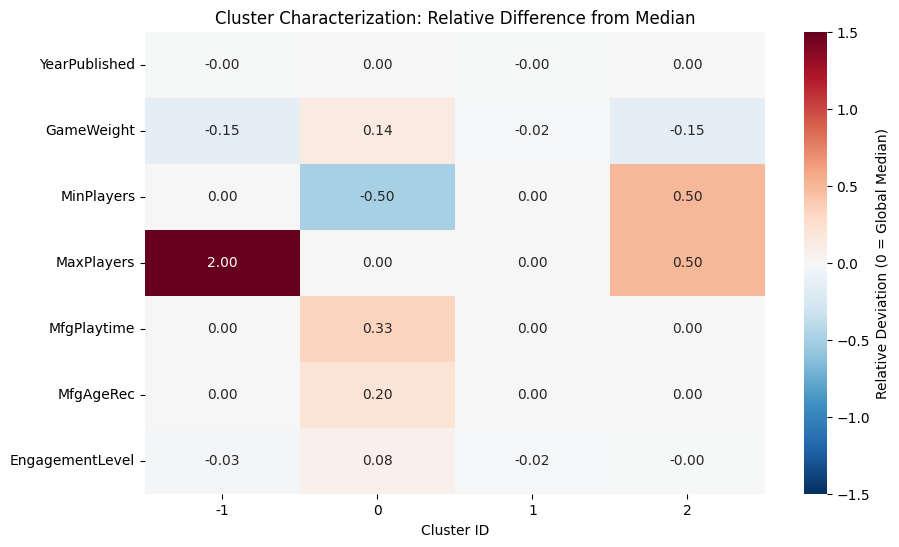

C:\Users\leona\AppData\Local\Temp\ipykernel_33852\1611386752.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df_analysis, ax=axes[i], palette='tab10')
C:\Users\leona\AppData\Local\Temp\ipykernel_33852\1611386752.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df_analysis, ax=axes[i], palette='tab10')
C:\Users\leona\AppData\Local\Temp\ipykernel_33852\1611386752.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df_analysis, ax=axes[i], palette='tab10')
C:\U

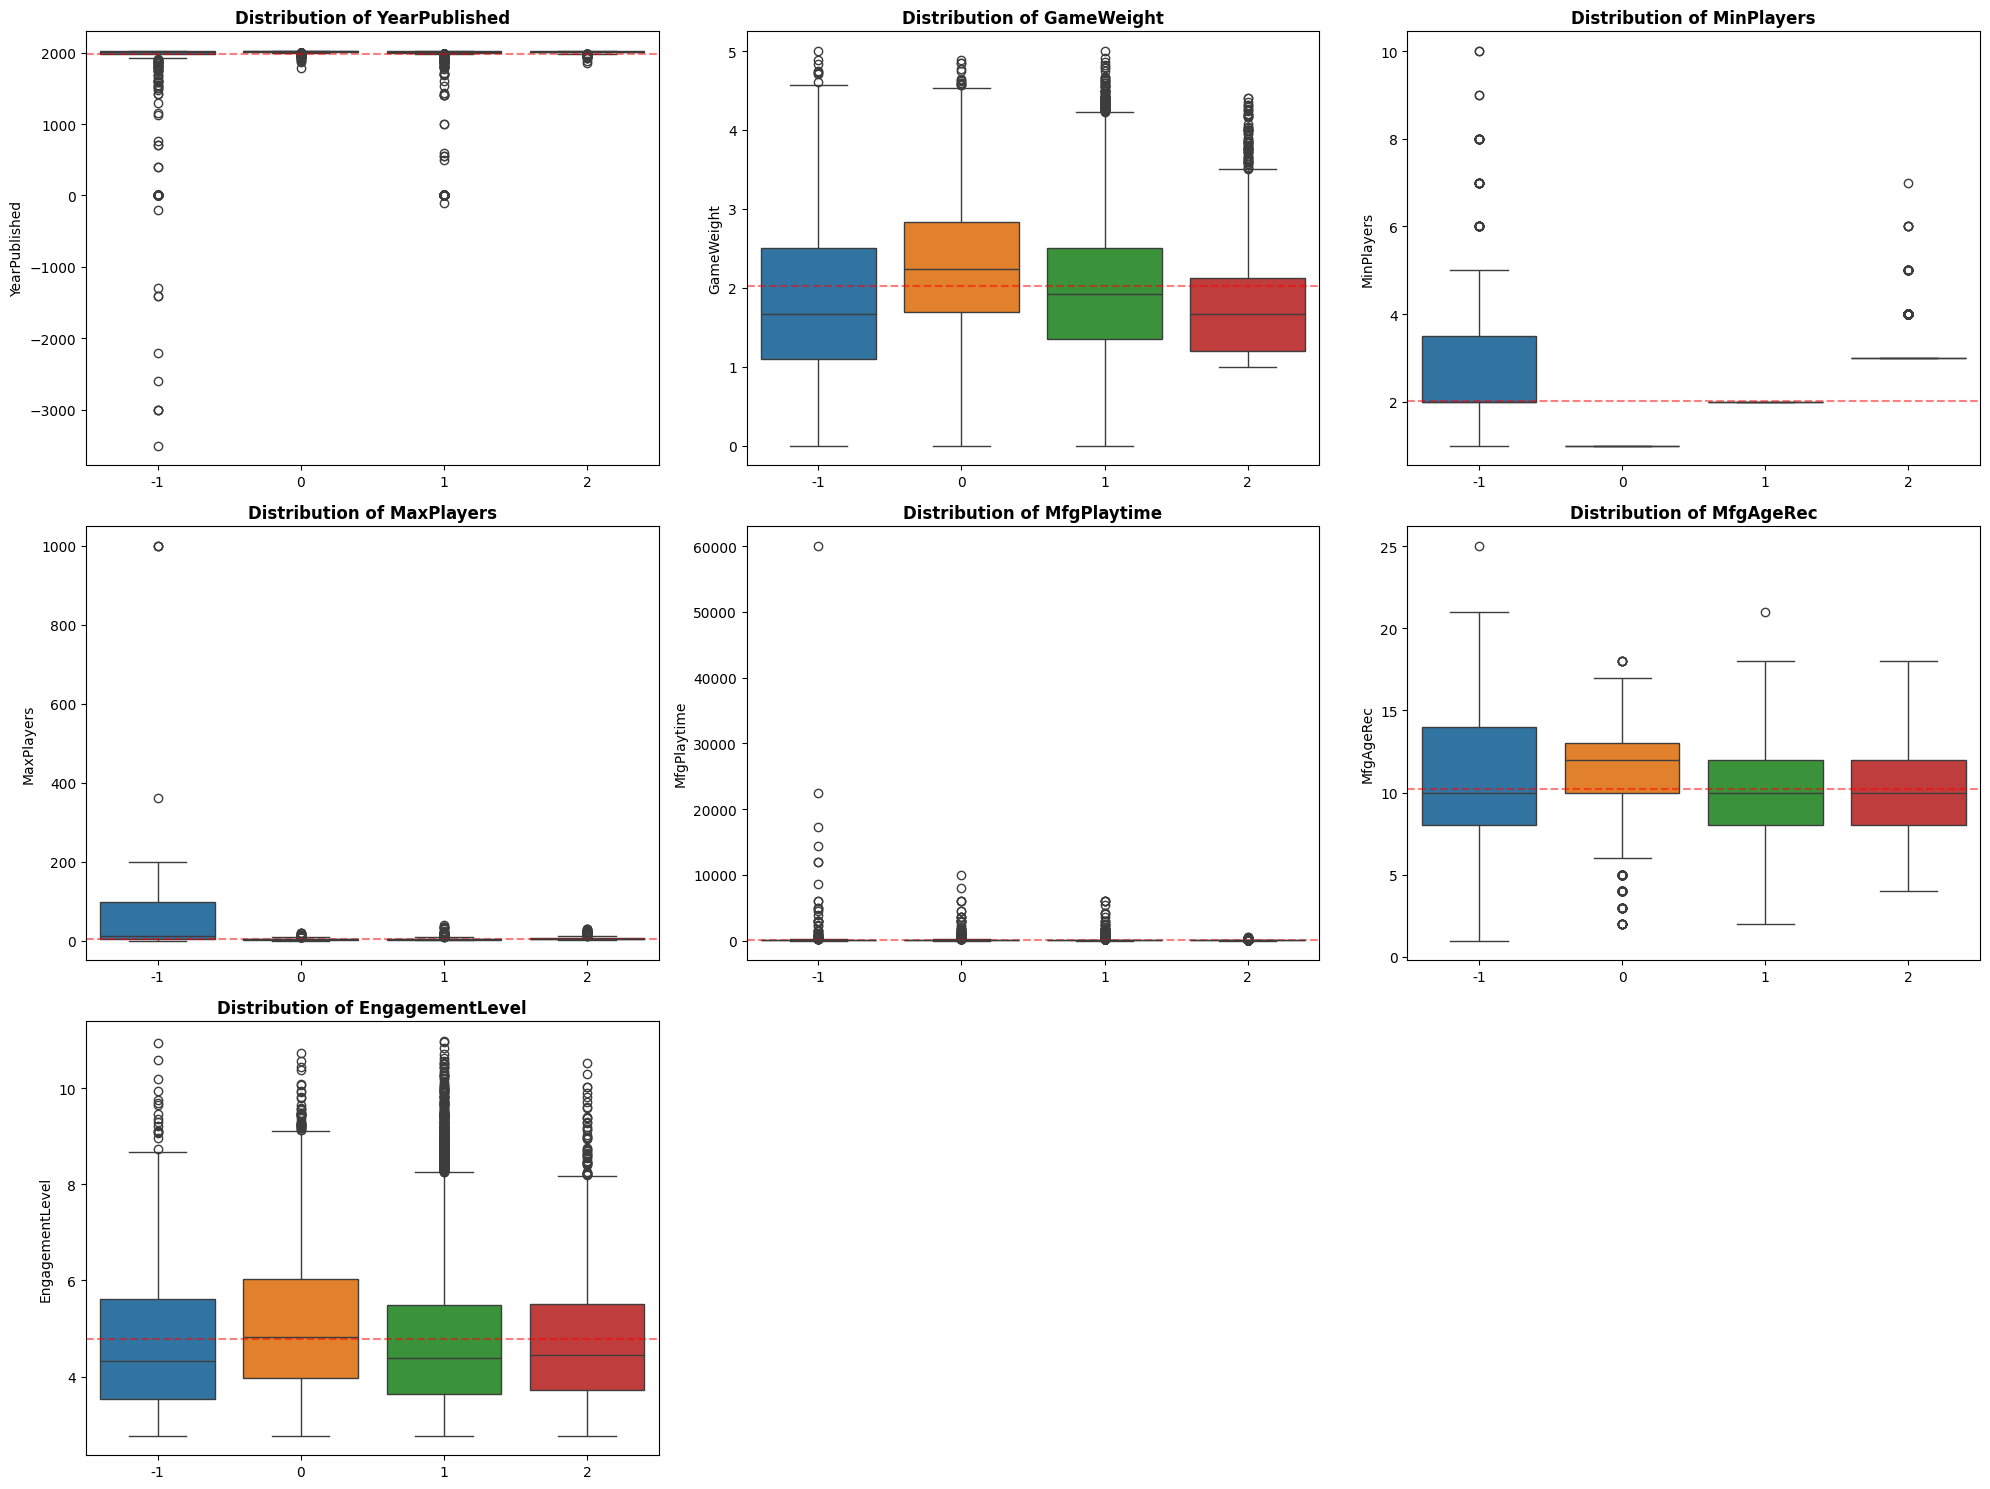


--- Analysis for Cluster -1 ---


,count,mean,std,min,25%,50%,75%,max
YearPublished,639.0,1659.20,831.52,-3500.00,1973.50,2009.00,2016.00,2021.00
GameWeight,639.0,1.92,1.01,0.00,1.10,1.67,2.50,5.00
MinPlayers,639.0,2.80,1.69,1.00,2.00,2.00,3.50,10.00
MaxPlayers,639.0,41.57,78.73,1.00,5.00,12.00,99.00,999.00
MfgPlaytime,639.0,402.53,2835.89,1.00,20.00,45.00,90.00,60000.00
MfgAgeRec,639.0,11.05,4.12,1.00,8.00,10.00,14.00,25.00
EngagementLevel,639.0,4.79,1.61,2.77,3.54,4.32,5.61,10.94



--- Analysis for Cluster 0 ---


,count,mean,std,min,25%,50%,75%,max
YearPublished,3643.0,2011.04,13.66,1783.00,2010.00,2016.00,2019.00,2021.00
GameWeight,3643.0,2.30,0.81,0.00,1.69,2.24,2.83,4.89
MinPlayers,3643.0,1.00,0.00,1.00,1.00,1.00,1.00,1.00
MaxPlayers,3643.0,4.06,2.11,1.00,2.00,4.00,5.00,20.00
MfgPlaytime,3643.0,121.84,363.60,2.00,30.00,60.00,120.00,10000.00
MfgAgeRec,3643.0,10.89,2.62,2.00,10.00,12.00,13.00,18.00
EngagementLevel,3643.0,5.12,1.45,2.77,3.98,4.82,6.03,10.74



--- Analysis for Cluster 1 ---


,count,mean,std,min,25%,50%,75%,max
YearPublished,14751.0,1988.88,179.57,-100.00,2000.00,2010.00,2016.00,2021.00
GameWeight,14751.0,2.00,0.78,0.00,1.34,1.93,2.50,5.00
MinPlayers,14751.0,2.00,0.00,2.00,2.00,2.00,2.00,2.00
MaxPlayers,14751.0,4.41,2.18,2.00,3.00,4.00,6.00,40.00
MfgPlaytime,14751.0,78.02,175.10,1.00,30.00,45.00,90.00,6000.00
MfgAgeRec,14751.0,9.93,2.62,2.00,8.00,10.00,12.00,21.00
EngagementLevel,14751.0,4.72,1.41,2.77,3.64,4.38,5.49,10.98



--- Analysis for Cluster 2 ---


,count,mean,std,min,25%,50%,75%,max
YearPublished,2846.0,2008.10,11.10,1860.00,2003.00,2011.00,2016.00,2021.00
GameWeight,2846.0,1.77,0.69,1.00,1.20,1.67,2.12,4.41
MinPlayers,2846.0,3.17,0.42,3.00,3.00,3.00,3.00,7.00
MaxPlayers,2846.0,6.65,2.84,3.00,5.00,6.00,8.00,30.00
MfgPlaytime,2846.0,56.14,49.17,5.00,30.00,45.00,60.00,600.00
MfgAgeRec,2846.0,10.65,2.57,4.00,8.00,10.00,12.00,18.00
EngagementLevel,2846.0,4.74,1.34,2.77,3.72,4.45,5.51,10.53


In [24]:
labels = hdb.labels_
# --- 1. Preparazione dei Dati per l'Analisi ---
# Copiamo il dataset filtrato per non sporcare l'originale
df_analysis = df_num.copy()
print(df_analysis.shape)
# Aggiungiamo le etichette dei cluster trovati
# Assicurati che 'kmeans' sia il tuo modello fittato e 'X_final' i dati usati
print(len(labels))
df_analysis['Cluster'] = labels

# --- IMPORTANTE: Inversione delle trasformazioni ---
# Per interpretare i dati, dobbiamo tornare ai valori originali (non logaritmici)
# Se hai la lista 'log_cols' dal tuo codice precedente:
if 'log_cols' in locals():
    print("Inverting log transformations for readability...")
    for col in log_cols:
        if col in df_analysis.columns:
            # Applichiamo expm1 (inverso di log1p)
            df_analysis[col] = np.expm1(df_analysis[col])

# ritraformazione di YearPublished in 'Anno' invece di 'Recency'
if 'YearPublished' in df_analysis.columns:
    df_analysis['YearPublished'] = df['YearPublished'].max() - df_analysis['YearPublished']

# --- 2. Tabella Riassuntiva (Centroidi Reali) ---
# Calcoliamo la mediana di ogni feature per ogni cluster
cluster_medians = df_analysis.groupby('Cluster').median()
cluster_counts = df_analysis['Cluster'].value_counts().sort_index()

# Aggiungiamo la dimensione del cluster per contesto
cluster_summary = cluster_medians.copy()
cluster_summary['Count'] = cluster_counts
cluster_summary['% Total'] = (cluster_counts / len(df_analysis)) * 100

print("\n--- Cluster Summary (Mean Values) ---")
# Trasponiamo per leggere meglio se hai tante colonne
display(cluster_summary.T.round(2))


# --- 3. Heatmap delle Differenze Relative (Profilazione) ---
# Questa visualizzazione risponde a: "In cosa questo cluster è diverso dalla mediana globale?"
# Rosso = Molto sopra la mediana, Blu = Molto sotto la mediana

global_median = df_analysis.drop(columns=['Cluster']).median()
# Calcoliamo la deviazione percentuale dalla mediana globale
relative_imp = (cluster_medians - global_median) / global_median

plt.figure(figsize=(10, 6))
sns.heatmap(data=relative_imp.T, 
            cmap='RdBu_r', 
            center=0, 
            annot=True, 
            fmt=".2f",
            vmax=1.5, vmin=-1.5, # Limita i colori estremi per leggibilità
            cbar_kws={'label': 'Relative Deviation (0 = Global Median)'})
plt.title('Cluster Characterization: Relative Difference from Median')
plt.xlabel('Cluster ID')
plt.show()


# --- 4. Boxplots Dettagliati (Distribuzione) ---
# I boxplot sono fondamentali per vedere se un cluster è "compatto" o "disperso"
# Creiamo un grafico per ogni feature numerica

features_to_plot = [col for col in df_analysis.columns if col not in ['Cluster']]
n_features = len(features_to_plot)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.boxplot(x='Cluster', y=col, data=df_analysis, ax=axes[i], palette='tab10')
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    
    # Linea tratteggiata rossa per la media globale
    global_avg = df_analysis[col].mean()
    axes[i].axhline(global_avg, color='red', linestyle='--', alpha=0.5, label='Global Avg')

# Rimuovi assi vuoti se ce ne sono
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# --- 5. Analisi divisa per Cluster ---
for cluster_id in sorted(df_analysis['Cluster'].unique()):
    print(f"\n--- Analysis for Cluster {cluster_id} ---")
    cluster_data = df_analysis[df_analysis['Cluster'] == cluster_id]
    # display statistics without the Cluster column
    display(cluster_data.drop(columns=['Cluster']).describe().T.round(2))

In [25]:
# check if clusters match some categorical features
# --- IGNORE ---
for i in range(len(set(labels))):
    cluster = np.where(labels == i)[0]
    cluster_indices = cluster
    cluster_data = df.iloc[cluster_indices]
    print(f"Cluster {i}:")
    print(f" Number of items: {len(cluster_data)}")
    for col in ['HasFamily', 'Category', 'Rating', 'Kickstarted', 'IsReimplementation','Rank','NumImplementations','NumExpansions','NumAlternates']:
        if col == 'Rank':
            median_rank = cluster_data[col].median()
            print(f"  Median {col}: {median_rank}")
            continue
        if col == 'NumImplementations':
            median_imp= cluster_data[col].median()
            print(f"  Median {col}: {median_imp}")
            continue
        if col == 'NumExpansions':
            median_exp = cluster_data[col].median()
            print(f"  Median {col}: {median_exp}")
            continue
        if col == 'NumAlternates':
            median_alt = cluster_data[col].median()
            print(f"  Median {col}: {median_alt}")
            continue
        
        value_counts = cluster_data[col].value_counts(normalize=True) * 100
        print(f"  {col} distribution:")
        print(value_counts)
    print("\n")   

Cluster 0:
 Number of items: 3643
  HasFamily distribution:
HasFamily
0    63.930826
1    36.069174
Name: proportion, dtype: float64
  Category distribution:
Category
NoCategory    47.378534
War           21.767774
Thematic      10.376064
Strategy       8.289871
Family         6.148778
Abstract       2.662641
Childrens      2.168542
CGS            0.686248
Party          0.521548
Name: proportion, dtype: float64
  Rating distribution:
Rating
High      43.672797
Medium    41.229756
Low       15.097447
Name: proportion, dtype: float64
  Kickstarted distribution:
Kickstarted
0    70.628603
1    29.371397
Name: proportion, dtype: float64
  IsReimplementation distribution:
IsReimplementation
0    87.427944
1    12.572056
Name: proportion, dtype: float64
  Median Rank: 2814.0
  Median NumImplementations: 0.0
  Median NumExpansions: 0.0
  Median NumAlternates: 0.0


Cluster 1:
 Number of items: 14751
  HasFamily distribution:
HasFamily
0    69.954579
1    30.045421
Name: proportion, dtype: fl

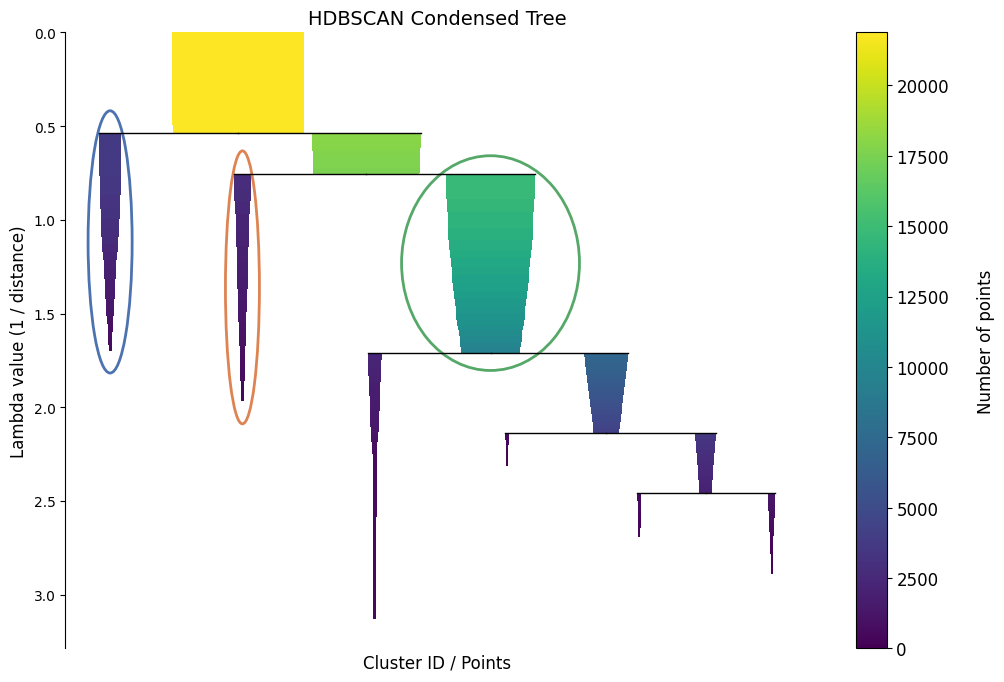

In [46]:
# hdbscan plot tree
import hdbscan
import seaborn as sns # Opzionale, ma rende i grafici più belli


clusterer = hdbscan.HDBSCAN(min_cluster_size=300,
        min_samples=5,
        metric='euclidean',
        gen_min_span_tree=True)
X_ready = np.array(X_scaled, dtype=np.float64)

# Riprova il fit
clusterer.fit(X_ready)

plt.figure(figsize=(12, 8))

# 1. Genera il plot standard
# (Salva l'oggetto axes principale, anche se per la colorbar agiremo sulla figura)
ax = clusterer.condensed_tree_.plot(select_clusters=True,
                                    selection_palette=sns.color_palette('deep', 8))

# 2. Modifica la Colorbar
# Recuperiamo la figura corrente
fig = plt.gcf() 

# La colorbar è tecnicamente un "asse" (axes) separato. 
# Le librerie di plotting di solito la aggiungono come ULTIMO asse della figura.
if len(fig.axes) > 1:
    cbar_ax = fig.axes[-1]  # Prendiamo l'ultimo asse (la barra laterale)
    
    # Reimpostiamo la label con il font desiderato
    cbar_ax.set_ylabel('Number of points', fontsize=12, labelpad=20)
    
    # Opzionale: Aumentare anche la grandezza dei numeri sulla barra
    cbar_ax.tick_params(labelsize=12) 

# 3. Modifica altri font del grafico principale (opzionale)
plt.title("HDBSCAN Condensed Tree", fontsize=14)
plt.xlabel("Cluster ID / Points", fontsize=12)
plt.ylabel("Lambda value (1 / distance)", fontsize=12)

plt.show()


In [42]:
print("Silhouette", silhouette_score(X_scaled[clusterer.labels_ != -1], clusterer.labels_[clusterer.labels_ != -1]))

Silhouette 0.11360859986270315


In [47]:
print("Noise percentage:", (list(clusterer.labels_).count(-1) / len(clusterer.labels_)) * 100)

Noise percentage: 3.272544449015037


(21879, 7)
21879
Inverting log transformations for readability...

--- Cluster Summary (Mean Values) ---


Cluster,-1,0,1,2
YearPublished,2008.00,2016.00,2011.00,2010.00
GameWeight,1.69,2.24,1.67,1.92
MinPlayers,2.00,1.00,3.00,2.00
MaxPlayers,10.00,4.00,6.00,4.00
MfgPlaytime,45.00,60.00,45.00,45.00
MfgAgeRec,10.00,12.00,10.00,10.00
EngagementLevel,4.32,4.82,4.45,4.38
Count,716.00,3643.00,2810.00,14710.00
% Total,3.27,16.65,12.84,67.23


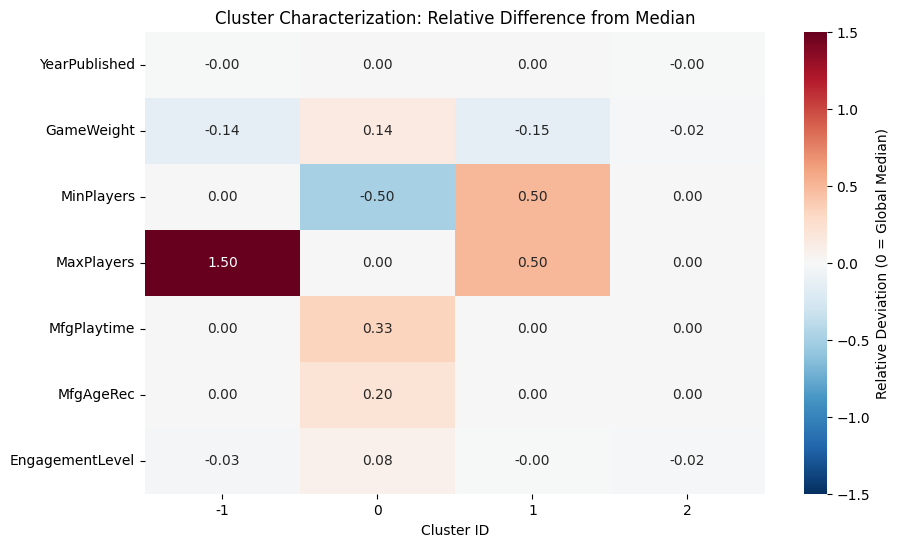

C:\Users\leona\AppData\Local\Temp\ipykernel_33852\2349013334.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df_analysis, ax=axes[i], palette='tab10')
C:\Users\leona\AppData\Local\Temp\ipykernel_33852\2349013334.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df_analysis, ax=axes[i], palette='tab10')
C:\Users\leona\AppData\Local\Temp\ipykernel_33852\2349013334.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df_analysis, ax=axes[i], palette='tab10')
C:\U

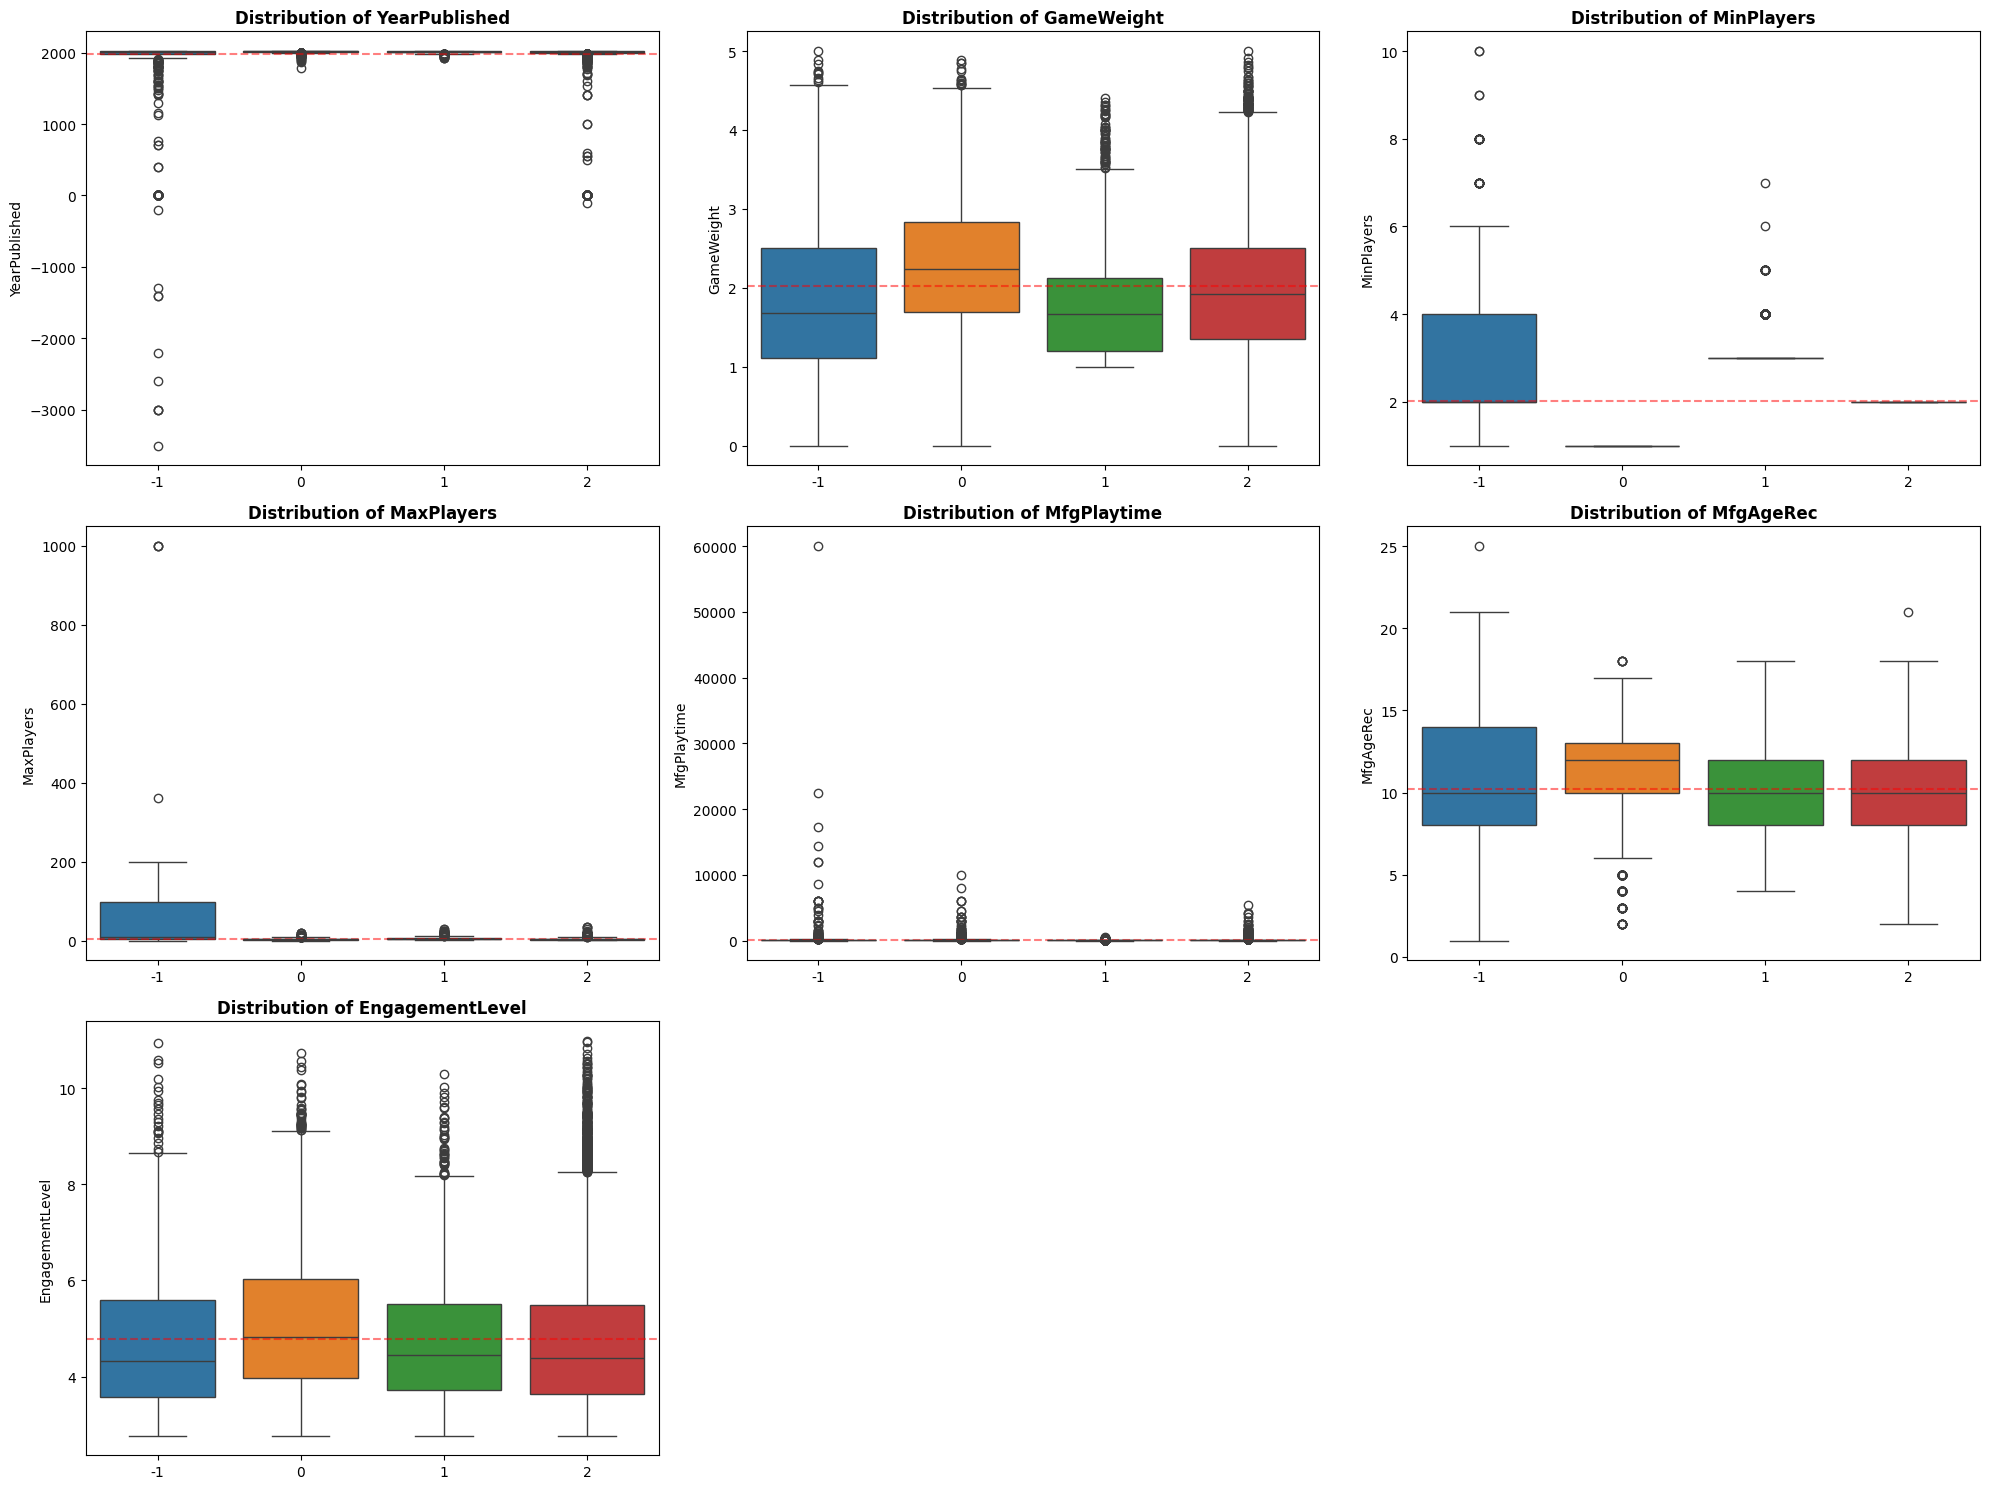


--- Analysis for Cluster -1 ---


,count,mean,std,min,25%,50%,75%,max
YearPublished,716.0,1678.74,804.16,-3500.00,1975.00,2008.00,2016.0,2021.00
GameWeight,716.0,1.94,1.03,0.00,1.11,1.69,2.5,5.00
MinPlayers,716.0,2.81,1.64,1.00,2.00,2.00,4.0,10.00
MaxPlayers,716.0,38.13,75.07,1.00,5.00,10.00,99.0,999.00
MfgPlaytime,716.0,410.63,2715.46,1.00,20.00,45.00,90.0,60000.00
MfgAgeRec,716.0,11.07,4.01,1.00,8.00,10.00,14.0,25.00
EngagementLevel,716.0,4.81,1.62,2.77,3.57,4.32,5.6,10.94



--- Analysis for Cluster 0 ---


,count,mean,std,min,25%,50%,75%,max
YearPublished,3643.0,2011.04,13.66,1783.00,2010.00,2016.00,2019.00,2021.00
GameWeight,3643.0,2.30,0.81,0.00,1.69,2.24,2.83,4.89
MinPlayers,3643.0,1.00,0.00,1.00,1.00,1.00,1.00,1.00
MaxPlayers,3643.0,4.06,2.11,1.00,2.00,4.00,5.00,20.00
MfgPlaytime,3643.0,121.84,363.60,2.00,30.00,60.00,120.00,10000.00
MfgAgeRec,3643.0,10.89,2.62,2.00,10.00,12.00,13.00,18.00
EngagementLevel,3643.0,5.12,1.45,2.77,3.98,4.82,6.03,10.74



--- Analysis for Cluster 1 ---


,count,mean,std,min,25%,50%,75%,max
YearPublished,2810.0,2008.20,10.49,1930.00,2003.00,2011.00,2016.00,2021.00
GameWeight,2810.0,1.77,0.69,1.00,1.20,1.67,2.12,4.41
MinPlayers,2810.0,3.16,0.40,3.00,3.00,3.00,3.00,7.00
MaxPlayers,2810.0,6.60,2.71,3.00,5.00,6.00,8.00,30.00
MfgPlaytime,2810.0,55.76,47.51,5.00,30.00,45.00,60.00,540.00
MfgAgeRec,2810.0,10.64,2.57,4.00,8.00,10.00,12.00,18.00
EngagementLevel,2810.0,4.74,1.33,2.77,3.73,4.45,5.51,10.30



--- Analysis for Cluster 2 ---


,count,mean,std,min,25%,50%,75%,max
YearPublished,14710.0,1989.68,175.88,-100.00,2000.00,2010.00,2016.00,2021.00
GameWeight,14710.0,2.00,0.78,0.00,1.34,1.92,2.50,5.00
MinPlayers,14710.0,2.00,0.00,2.00,2.00,2.00,2.00,2.00
MaxPlayers,14710.0,4.40,2.12,2.00,3.00,4.00,6.00,36.00
MfgPlaytime,14710.0,75.94,142.71,1.00,30.00,45.00,90.00,5400.00
MfgAgeRec,14710.0,9.92,2.62,2.00,8.00,10.00,12.00,21.00
EngagementLevel,14710.0,4.72,1.41,2.77,3.64,4.38,5.49,10.98


In [43]:
labels = clusterer.labels_
# --- 1. Preparazione dei Dati per l'Analisi ---
# Copiamo il dataset filtrato per non sporcare l'originale
df_analysis = df_num.copy()
print(df_analysis.shape)
# Aggiungiamo le etichette dei cluster trovati
# Assicurati che 'kmeans' sia il tuo modello fittato e 'X_final' i dati usati
print(len(labels))
df_analysis['Cluster'] = labels

# --- IMPORTANTE: Inversione delle trasformazioni ---
# Per interpretare i dati, dobbiamo tornare ai valori originali (non logaritmici)
# Se hai la lista 'log_cols' dal tuo codice precedente:
if 'log_cols' in locals():
    print("Inverting log transformations for readability...")
    for col in log_cols:
        if col in df_analysis.columns:
            # Applichiamo expm1 (inverso di log1p)
            df_analysis[col] = np.expm1(df_analysis[col])

# ritraformazione di YearPublished in 'Anno' invece di 'Recency'
if 'YearPublished' in df_analysis.columns:
    df_analysis['YearPublished'] = df['YearPublished'].max() - df_analysis['YearPublished']

# --- 2. Tabella Riassuntiva (Centroidi Reali) ---
# Calcoliamo la mediana di ogni feature per ogni cluster
cluster_medians = df_analysis.groupby('Cluster').median()
cluster_counts = df_analysis['Cluster'].value_counts().sort_index()

# Aggiungiamo la dimensione del cluster per contesto
cluster_summary = cluster_medians.copy()
cluster_summary['Count'] = cluster_counts
cluster_summary['% Total'] = (cluster_counts / len(df_analysis)) * 100

print("\n--- Cluster Summary (Mean Values) ---")
# Trasponiamo per leggere meglio se hai tante colonne
display(cluster_summary.T.round(2))


# --- 3. Heatmap delle Differenze Relative (Profilazione) ---
# Questa visualizzazione risponde a: "In cosa questo cluster è diverso dalla mediana globale?"
# Rosso = Molto sopra la mediana, Blu = Molto sotto la mediana

global_median = df_analysis.drop(columns=['Cluster']).median()
# Calcoliamo la deviazione percentuale dalla mediana globale
relative_imp = (cluster_medians - global_median) / global_median

plt.figure(figsize=(10, 6))
sns.heatmap(data=relative_imp.T, 
            cmap='RdBu_r', 
            center=0, 
            annot=True, 
            fmt=".2f",
            vmax=1.5, vmin=-1.5, # Limita i colori estremi per leggibilità
            cbar_kws={'label': 'Relative Deviation (0 = Global Median)'})
plt.title('Cluster Characterization: Relative Difference from Median')
plt.xlabel('Cluster ID')
plt.show()


# --- 4. Boxplots Dettagliati (Distribuzione) ---
# I boxplot sono fondamentali per vedere se un cluster è "compatto" o "disperso"
# Creiamo un grafico per ogni feature numerica

features_to_plot = [col for col in df_analysis.columns if col not in ['Cluster']]
n_features = len(features_to_plot)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.boxplot(x='Cluster', y=col, data=df_analysis, ax=axes[i], palette='tab10')
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    
    # Linea tratteggiata rossa per la media globale
    global_avg = df_analysis[col].mean()
    axes[i].axhline(global_avg, color='red', linestyle='--', alpha=0.5, label='Global Avg')

# Rimuovi assi vuoti se ce ne sono
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# --- 5. Analisi divisa per Cluster ---
for cluster_id in sorted(df_analysis['Cluster'].unique()):
    print(f"\n--- Analysis for Cluster {cluster_id} ---")
    cluster_data = df_analysis[df_analysis['Cluster'] == cluster_id]
    # display statistics without the Cluster column
    display(cluster_data.drop(columns=['Cluster']).describe().T.round(2))

In [40]:
# check if clusters match some categorical features
# --- IGNORE ---
for i in range(len(set(labels))):
    cluster = np.where(labels == i)[0]
    cluster_indices = cluster
    cluster_data = df.iloc[cluster_indices]
    print(f"Cluster {i}:")
    print(f" Number of items: {len(cluster_data)}")
    for col in ['HasFamily', 'Category', 'Rating', 'Kickstarted', 'IsReimplementation','Rank','NumImplementations','NumExpansions','NumAlternates']:
        if col == 'Rank':
            median_rank = cluster_data[col].median()
            print(f"  Median {col}: {median_rank}")
            continue
        if col == 'NumImplementations':
            median_imp= cluster_data[col].median()
            print(f"  Median {col}: {median_imp}")
            continue
        if col == 'NumExpansions':
            median_exp = cluster_data[col].median()
            print(f"  Median {col}: {median_exp}")
            continue
        if col == 'NumAlternates':
            median_alt = cluster_data[col].median()
            print(f"  Median {col}: {median_alt}")
            continue
        
        value_counts = cluster_data[col].value_counts(normalize=True) * 100
        print(f"  {col} distribution:")
        print(value_counts)
    print("\n")   

Cluster 0:
 Number of items: 3643
  HasFamily distribution:
HasFamily
0    63.930826
1    36.069174
Name: proportion, dtype: float64
  Category distribution:
Category
NoCategory    47.378534
War           21.767774
Thematic      10.376064
Strategy       8.289871
Family         6.148778
Abstract       2.662641
Childrens      2.168542
CGS            0.686248
Party          0.521548
Name: proportion, dtype: float64
  Rating distribution:
Rating
High      43.672797
Medium    41.229756
Low       15.097447
Name: proportion, dtype: float64
  Kickstarted distribution:
Kickstarted
0    70.628603
1    29.371397
Name: proportion, dtype: float64
  IsReimplementation distribution:
IsReimplementation
0    87.427944
1    12.572056
Name: proportion, dtype: float64
  Median Rank: 2814.0
  Median NumImplementations: 0.0
  Median NumExpansions: 0.0
  Median NumAlternates: 0.0


Cluster 1:
 Number of items: 2810
  HasFamily distribution:
HasFamily
0    77.402135
1    22.597865
Name: proportion, dtype: flo